# Previsione delle Piogge in Australia
## Progetto di Machine Learning — Master ADABI

---

### Contesto e obiettivo

Questo progetto affronta un problema di **classificazione binaria**: prevedere se il giorno successivo pioverà oppure no in una delle 49 stazioni meteorologiche australiane. La variabile target è `RainTomorrow`, che vale "Si" se il giorno seguente si registreranno più di 1 mm di precipitazioni, "No" altrimenti.

I dati provengono dall'**Australian Bureau of Meteorology**, l'ente meteorologico ufficiale australiano, e coprono circa 10 anni di osservazioni giornaliere (2008-2017) distribuite su 49 città dell'intero territorio australiano, per un totale di circa 145.000 osservazioni.

Una considerazione importante guida l'intero lavoro: un **falso negativo** — prevedere "non piove" quando invece piove — è più costoso di un **falso positivo**. Nel primo caso una persona potrebbe trovarsi senza ombrello, un sistema di allerta potrebbe non attivarsi in tempo. Nel secondo si porta un ombrello inutile: fastidioso ma innocuo. Questa asimmetria nel costo degli errori ha guidato la scelta della metrica di ottimizzazione durante il tuning degli iperparametri, dove si è preferito massimizzare il **recall** invece dell'accuracy o dell'F1.

---

### Descrizione delle variabili originali

Il dataset contiene 23 colonne originali: 16 numeriche, 4 categoriche, 1 data e il target.

| Variabile | Tipo | Descrizione |
|---|---|---|
| `Date` | Data | Data dell'osservazione → trasformata in `Month` e `Year` |
| `Location` | Categorica | Città (49 stazioni) → sostituita con `Latitude` e `Longitude` |
| `MinTemp` | Numerica | Temperatura minima giornaliera (°C) |
| `MaxTemp` | Numerica | Temperatura massima giornaliera (°C) |
| `Rainfall` | Numerica | Precipitazioni del giorno corrente (mm) |
| `Evaporation` | Numerica | Evaporazione giornaliera (mm) — **rimossa** (~43% NA) |
| `Sunshine` | Numerica | Ore di sole — **rimossa** (~48% NA) |
| `WindGustDir` | Categorica | Direzione raffica massima → **encoding circolare** (sin/cos) |
| `WindGustSpeed` | Numerica | Velocità raffica massima (km/h) |
| `WindDir9am` | Categorica | Direzione vento ore 9:00 → **encoding circolare** |
| `WindDir3pm` | Categorica | Direzione vento ore 15:00 → **encoding circolare** |
| `WindSpeed9am` | Numerica | Velocità vento ore 9:00 (km/h) |
| `WindSpeed3pm` | Numerica | Velocità vento ore 15:00 (km/h) |
| `Humidity9am` | Numerica | Umidità relativa ore 9:00 (%) |
| `Humidity3pm` | Numerica | Umidità relativa ore 15:00 (%) |
| `Pressure9am` | Numerica | Pressione atmosferica ore 9:00 (hPa) |
| `Pressure3pm` | Numerica | Pressione atmosferica ore 15:00 (hPa) |
| `Cloud9am` | Numerica | Copertura nuvolosa ore 9:00 — **rimossa** (~38% NA) |
| `Cloud3pm` | Numerica | Copertura nuvolosa ore 15:00 — **rimossa** (~40% NA) |
| `Temp9am` | Numerica | Temperatura ore 9:00 (°C) |
| `Temp3pm` | Numerica | Temperatura ore 15:00 (°C) |
| `RainToday` | Binaria | Ha piovuto oggi? Yes/No → 1/0 |
| `RainTomorrow` | Binaria | **TARGET** — Pioverà domani? Yes/No → 1/0 |

Oltre alle variabili originali, il preprocessing crea quattro **nuove feature** tramite feature engineering: `TempRange`, `PressureDrop`, `HumidityRise` e `Season`.

---

### Pipeline metodologica

Il progetto segue una pipeline in sette fasi:

1. **EDA** — distribuzioni, valori mancanti, correlazioni, stagionalità
2. **Preprocessing pre-split** — pulizia, encoding e feature engineering (trasformazioni deterministiche)
3. **Divisione del dataset** — split stratificato 60/20/20
4. **Imputazione e scaling post-split** — per evitare data leakage
5. **Addestramento con parametri default** — confronto di quattro algoritmi sul validation set
6. **Hyperparameter tuning** — ottimizzazione con cross-validation sul solo training set
7. **Valutazione finale** — test set toccato una sola volta alla fine

## 1 · Importazione librerie

Si importano le librerie necessarie per l'analisi: `pandas` e `numpy` per la gestione dei dati, `matplotlib` e `seaborn` per i grafici, e i moduli di `sklearn` per preprocessing, modellazione e valutazione.

In [58]:
import sklearn
print(sklearn.__version__)   #deve essere >= 1.6.1

1.7.2


In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

sns.set_theme(style='whitegrid')
plt.rc('font', size=13)
plt.rc('axes', labelsize=13, titlesize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

## 2 · Caricamento e prima esplorazione

Il primo passo è caricare il dataset e osservare le sue caratteristiche fondamentali: dimensioni, tipi di variabili, prime righe e statistiche descrittive. Questa fase serve a orientarsi prima di qualsiasi trasformazione.

In [60]:
df = pd.read_csv('weatherAUS.csv')
print(f'Dimensioni: {df.shape[0]:,} righe x {df.shape[1]} colonne')
display(df.head(10))

Dimensioni: 145,460 righe x 23 colonne


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No
5,2008-12-06,Albury,14.6,29.7,0.2,NaN,NaN,WNW,56.0,W,...,55.0,23.0,1009.2,1005.4,NaN,NaN,20.6,28.9,No,No
6,2008-12-07,Albury,14.3,25.0,0.0,NaN,NaN,W,50.0,SW,...,49.0,19.0,1009.6,1008.2,1.0,NaN,18.1,24.6,No,No
7,2008-12-08,Albury,7.7,26.7,0.0,NaN,NaN,W,35.0,SSE,...,48.0,19.0,1013.4,1010.1,NaN,NaN,16.3,25.5,No,No
8,2008-12-09,Albury,9.7,31.9,0.0,NaN,NaN,NNW,80.0,SE,...,42.0,9.0,1008.9,1003.6,NaN,NaN,18.3,30.2,No,Yes
9,2008-12-10,Albury,13.1,30.1,1.4,NaN,NaN,W,28.0,S,...,58.0,27.0,1007.0,1005.7,NaN,NaN,20.1,28.2,Yes,No


In [61]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

None

In [62]:
display(df.describe().round(2))

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,143975.00,144199.00,142199.00,82670.00,75625.00,135197.00,143693.00,142398.00,142806.00,140953.00,130395.00,130432.00,89572.00,86102.00,143693.00,141851.00
mean,12.19,23.22,2.36,5.47,7.61,40.04,14.04,18.66,68.88,51.54,1017.65,1015.26,4.45,4.51,16.99,21.68
std,6.40,7.12,8.48,4.19,3.79,13.61,8.92,8.81,19.03,20.80,7.11,7.04,2.89,2.72,6.49,6.94
min,-8.50,-4.80,0.00,0.00,0.00,6.00,0.00,0.00,0.00,0.00,980.50,977.10,0.00,0.00,-7.20,-5.40
25%,7.60,17.90,0.00,2.60,4.80,31.00,7.00,13.00,57.00,37.00,1012.90,1010.40,1.00,2.00,12.30,16.60
50%,12.00,22.60,0.00,4.80,8.40,39.00,13.00,19.00,70.00,52.00,1017.60,1015.20,5.00,5.00,16.70,21.10
75%,16.90,28.20,0.80,7.40,10.60,48.00,19.00,24.00,83.00,66.00,1022.40,1020.00,7.00,7.00,21.60,26.40
max,33.90,48.10,371.00,145.00,14.50,135.00,130.00,87.00,100.00,100.00,1041.00,1039.60,9.00,9.00,40.20,46.70


Il dataset contiene 145.460 osservazioni e 23 colonne. Si nota subito una varietà di tipi: variabili continue (temperature, pressioni, umidità), categoriche (posizione, direzione del vento) e binarie (RainToday, RainTomorrow). Le statistiche descrittive confermano range ragionevoli per dati meteorologici reali: temperature tra -8°C e 48°C, pressioni tra 980 e 1040 hPa, umidità tra 0 e 100%.

## 3 · Analisi Esplorativa (EDA)

L'esplorazione dei dati è la fase in cui si impara a conoscere il dataset prima di toccarlo. L'obiettivo è identificare problemi come valori mancanti e outlier, capire la distribuzione del target e ricavare intuizioni che guideranno le scelte successive.

### 3.1 · Valori mancanti

I valori mancanti sono frequenti nei dati meteorologici reali: una stazione può guastarsi, un sensore può non registrare. Prima di decidere come gestirli è necessario capire quanti ce ne sono e dove si concentrano, per scegliere la strategia più adatta.

In [63]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Valori mancanti': missing, 'Percentuale %': missing_pct})
missing_df = missing_df[missing_df['Valori mancanti'] > 0].sort_values('Percentuale %', ascending=False)
display(missing_df)

,Valori mancanti,Percentuale %
Sunshine,69835,48.01
Evaporation,62790,43.17
Cloud3pm,59358,40.81
Cloud9am,55888,38.42
Pressure9am,15065,10.36
Pressure3pm,15028,10.33
WindDir9am,10566,7.26
WindGustDir,10326,7.10
WindGustSpeed,10263,7.06
Humidity3pm,4507,3.10


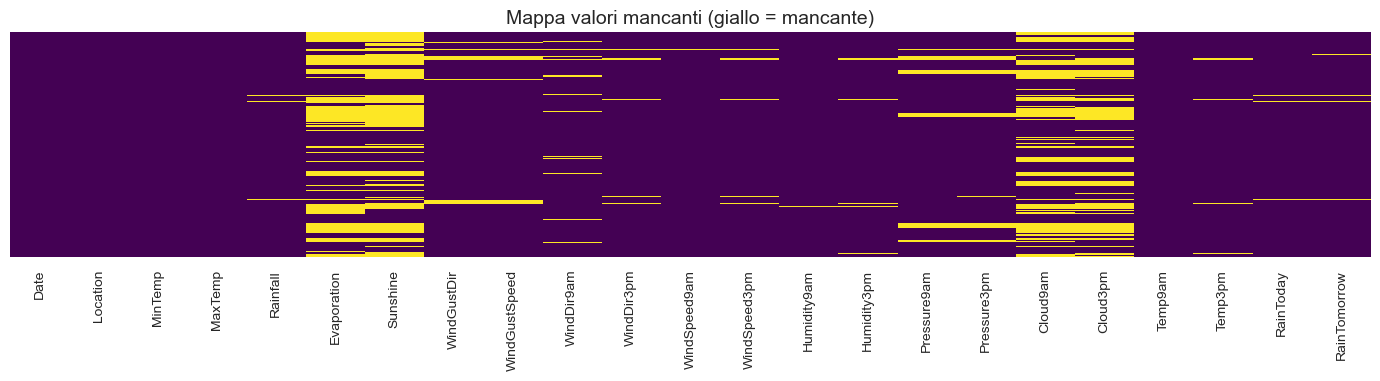

In [64]:
plt.figure(figsize=(14, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Mappa valori mancanti (giallo = mancante)')
plt.tight_layout()
plt.show()

Quattro colonne si distinguono per la percentuale molto elevata di NA: `Sunshine` (~48%), `Evaporation` (~43%), `Cloud3pm` (~40%) e `Cloud9am` (~38%). Con quote così alte qualsiasi strategia di imputazione introdurrebbe troppo rumore artificiale — si starebbero di fatto inventando quasi metà dei valori — per cui la scelta più onesta è eliminarle direttamente. Le colonne rimanenti presentano percentuali molto più contenute (in genere sotto il 10%) e verranno gestite con imputazione per mediana dopo lo split.

### 3.2 · Bilanciamento delle classi

Prima di procedere è fondamentale verificare quanto sono bilanciate le due classi del target. Un forte sbilanciamento impatta direttamente le scelte di modellazione: un modello che predicesse sempre "non piove" raggiungerebbe un'accuracy del 78% senza aver imparato nulla. Per questo motivo l'accuracy non sarà la metrica principale.

Distribuzione RainTomorrow:


,Conteggio,Percentuale %
RainTomorrow,,
No,110316,77.58
Yes,31877,22.42


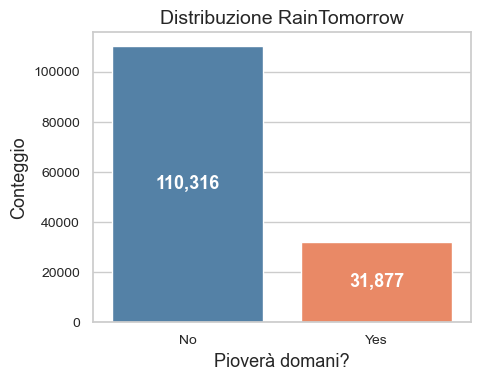

In [65]:
target_counts = df['RainTomorrow'].value_counts()
target_pct = df['RainTomorrow'].value_counts(normalize=True) * 100
print('Distribuzione RainTomorrow:')
display(pd.DataFrame({'Conteggio': target_counts, 'Percentuale %': target_pct.round(2)}))

plt.figure(figsize=(5, 4))
ax = sns.countplot(x='RainTomorrow', data=df, hue='RainTomorrow',
                   palette=['steelblue','coral'], legend=False)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x()+p.get_width()/2., p.get_height()/2),
                ha='center', va='center', color='white', fontweight='bold')
plt.title('Distribuzione RainTomorrow')
plt.xlabel('Pioverà domani?')
plt.ylabel('Conteggio')
plt.tight_layout()
plt.show()

Il dataset è **sbilanciato**: circa il 78% dei giorni non piove, solo il 22% piove. Questo squilibrio ha due conseguenze dirette sul lavoro. Prima: le metriche da privilegiare sono recall, F1-Score e ROC-AUC, non l'accuracy. Seconda: durante l'addestramento occorre compensare lo sbilanciamento per evitare che il modello impari a ignorare la classe minoritaria. Questo verrà fatto con `class_weight='balanced'` per tutti i modelli che lo supportano e con `sample_weight` per la Rete Neurale, che non ha questo parametro.

### 3.3 · Distribuzioni variabili numeriche

Osservare la forma delle distribuzioni aiuta a capire la natura di ogni variabile: se è approssimativamente normale, asimmetrica, o presenta valori anomali. Questo informa le scelte di preprocessing come l'imputazione e lo scaling.

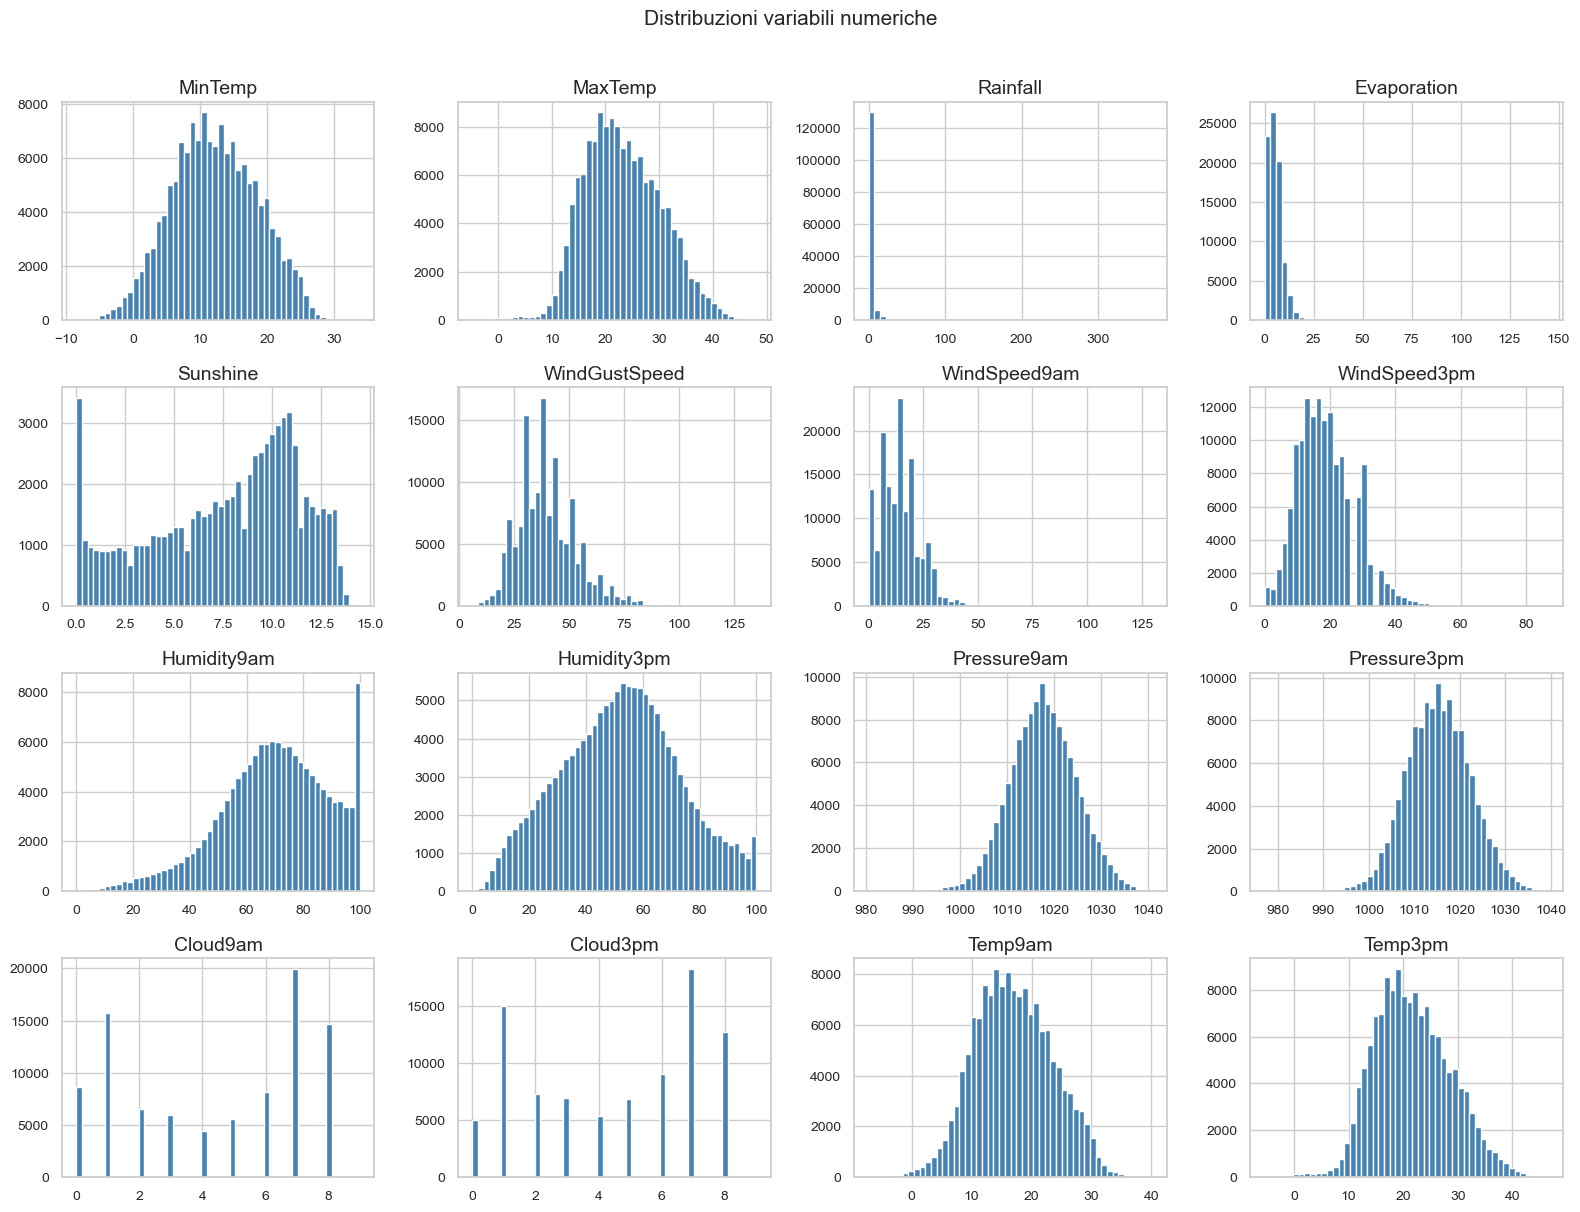

In [66]:
num_cols_eda = df.select_dtypes(include='number').columns.tolist()
df[num_cols_eda].hist(bins=50, figsize=(16, 12), color='steelblue', edgecolor='white')
plt.suptitle('Distribuzioni variabili numeriche', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

Le variabili di temperatura e pressione mostrano distribuzioni approssimativamente normali, compatibili con misurazioni fisiche reali. `Rainfall` è invece fortemente asimmetrica verso destra: la stragrande maggioranza dei giorni non registra precipitazioni, e solo pochi giorni mostrano valori elevati. Questa asimmetria suggerisce di usare la **mediana** piuttosto che la media per l'imputazione dei valori mancanti, perché la mediana è robusta ai valori estremi e non viene trascinata verso l'alto dai giorni di pioggia intensa.

### 3.4 · Matrice di correlazione

La matrice di correlazione permette di identificare variabili ridondanti (fortemente correlate tra loro). Va analizzata qui, durante l'EDA, perché orienta le scelte di preprocessing e modellazione.

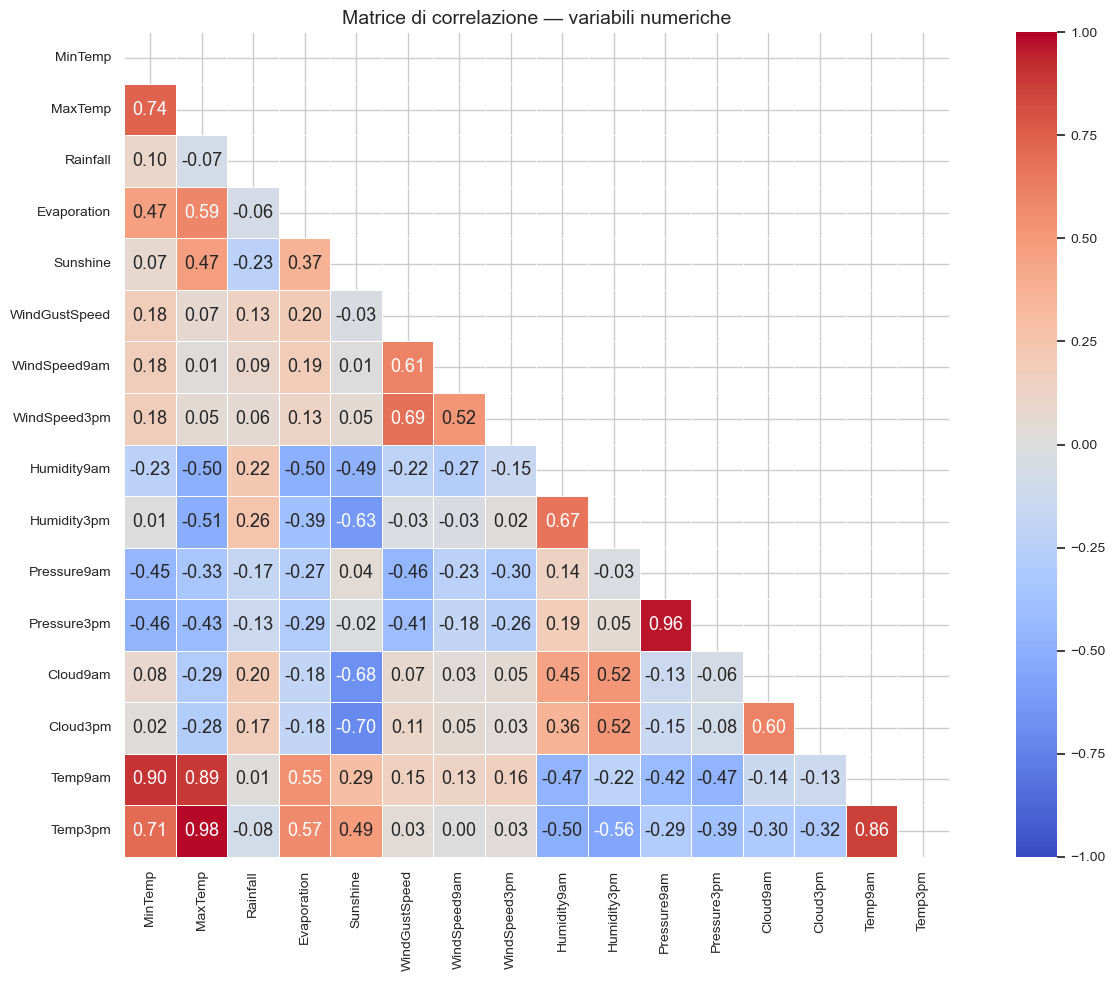

In [67]:
corr = df[num_cols_eda].corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(14, 10))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, linewidths=0.5, square=True)
plt.title('Matrice di correlazione — variabili numeriche')
plt.tight_layout()
plt.show()

Emergono due gruppi di variabili fortemente correlate. Il primo riguarda le **temperature**: `MinTemp`, `MaxTemp`, `Temp9am` e `Temp3pm` si muovono quasi in parallelo (r > 0.70), cosa ovvia dato che misurano tutte la temperatura della stessa giornata. Il secondo riguarda la **pressione**: `Pressure9am` e `Pressure3pm` sono quasi identiche (r ≈ 0.96).

Si è scelto di **non rimuovere** queste variabili correlate, per due motivi: i modelli basati su alberi (Decision Tree, Random Forest) gestiscono la multicollinearità autonomamente selezionando la feature più informativa ad ogni split; e rimuovere variabili in modo arbitrario potrebbe eliminare informazione utile per i modelli più complessi come la Rete Neurale. L'impatto sulla Regressione Logistica — più sensibile alla multicollinearità — viene discusso nella sezione dei risultati.

### 3.5 · Boxplot — analisi degli outlier

I boxplot mostrano la distribuzione di ogni variabile e i valori che si discostano significativamente dal range tipico (punti fuori dai baffi). Capire dove si trovano gli outlier aiuta a decidere se intervenire o lasciarli così.

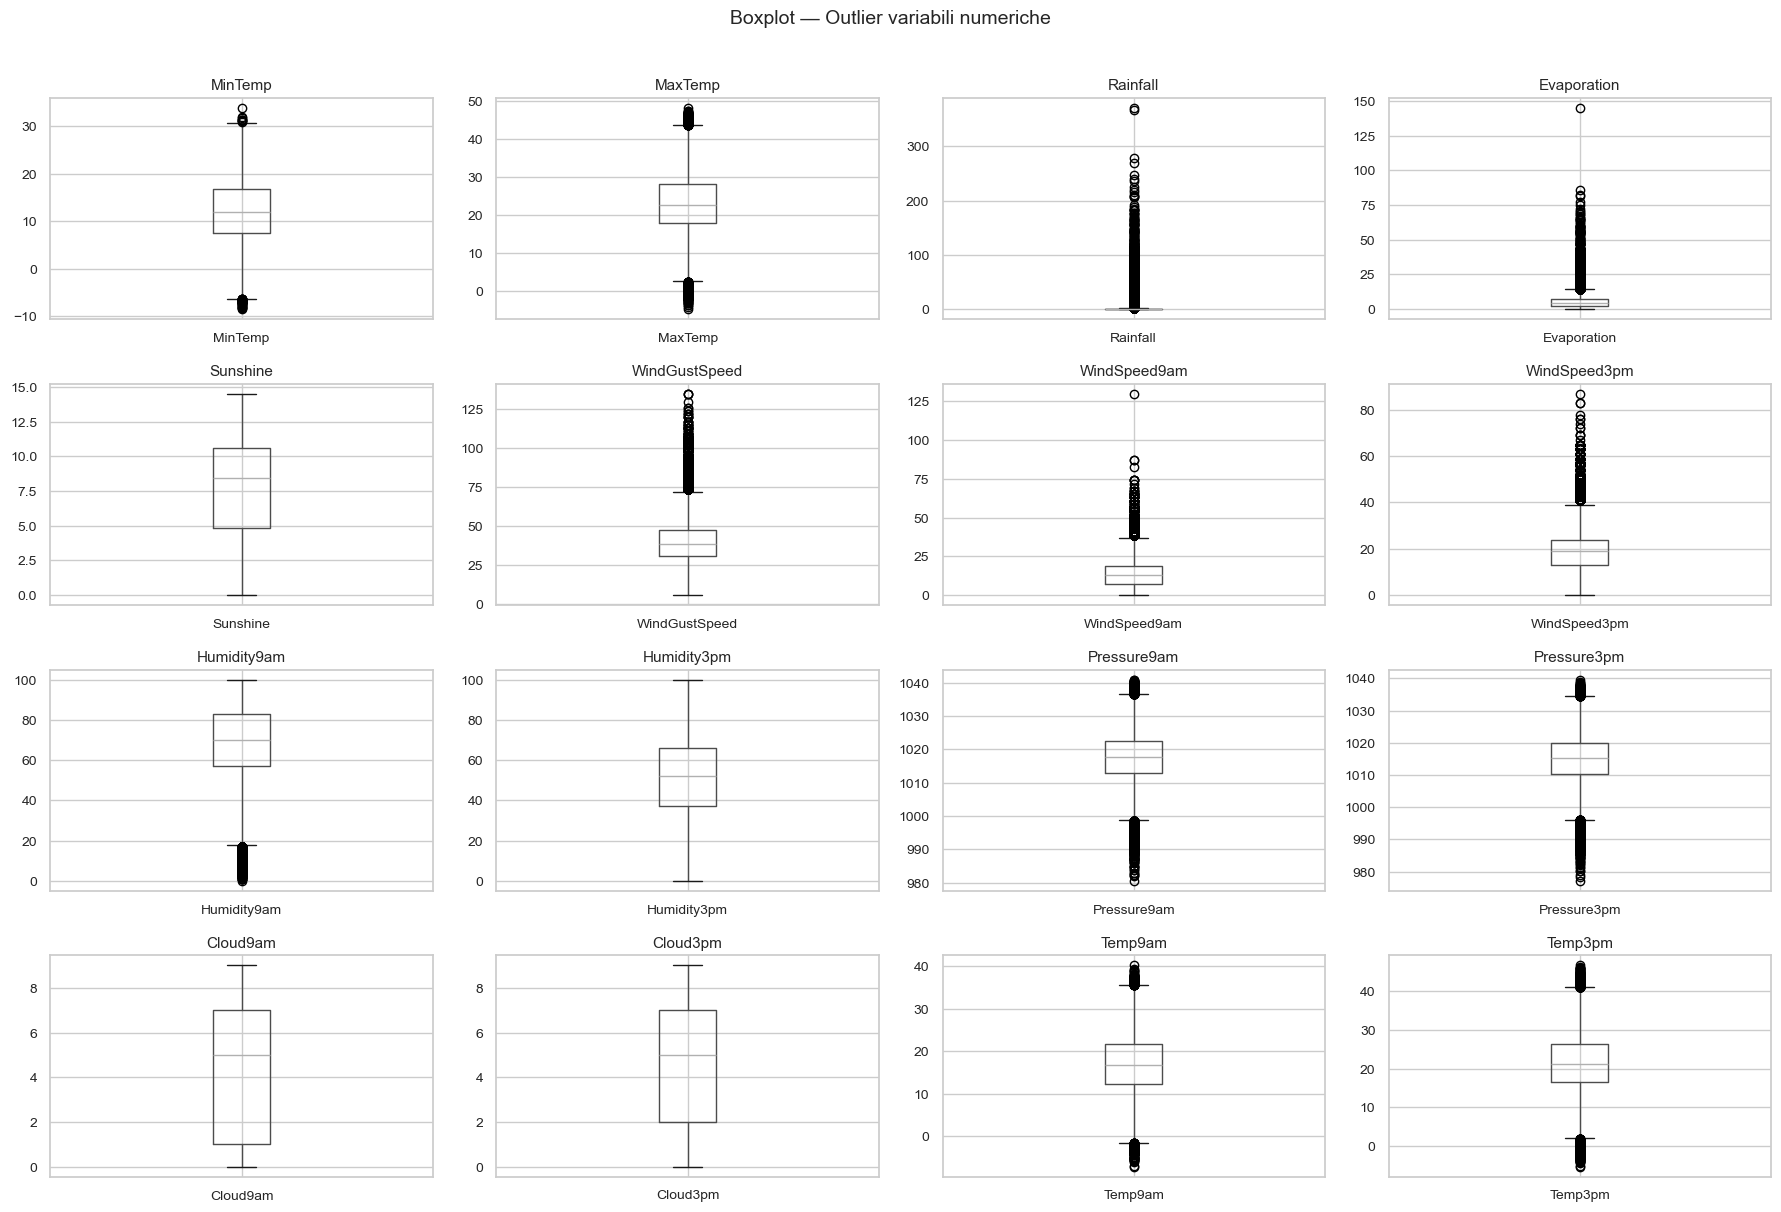

In [69]:
n_cols_plot = 4
n_rows_plot = (len(num_cols_eda) + n_cols_plot - 1) // n_cols_plot
fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(18, n_rows_plot * 3))
axes = axes.flatten()

for i, col in enumerate(num_cols_eda):
    df.boxplot(column=col, ax=axes[i])
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)): axes[j].set_visible(False)

plt.suptitle('Boxplot — Outlier variabili numeriche', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

I boxplot rivelano outlier in diverse variabili, particolarmente marcati in `Rainfall`, `WindGustSpeed` e `WindSpeed3pm`. Si è scelto di **non rimuoverli né clipparli**, per due ragioni. Prima: si tratta di dati meteorologici ufficiali del Bureau of Meteorology — un valore estremo di vento o pioggia rappresenta un evento reale (temporale, ciclone) che il modello dovrebbe poter riconoscere. Seconda: la strategia di imputazione per mediana è robusta alla presenza di outlier, dunque il loro impatto sull'imputazione è limitato. I modelli basati su alberi inoltre non risentono degli outlier nelle feature.

### 3.6 · Distribuzione stagionale delle piogge

L'Australia è un continente con climi molto diversi — tropicale al nord, temperato al sud, desertico al centro. Verificare se la probabilità di pioggia cambia nel corso dell'anno è importante: se esiste una stagionalità marcata, il mese diventa una feature predittiva che vale la pena includere nel modello.

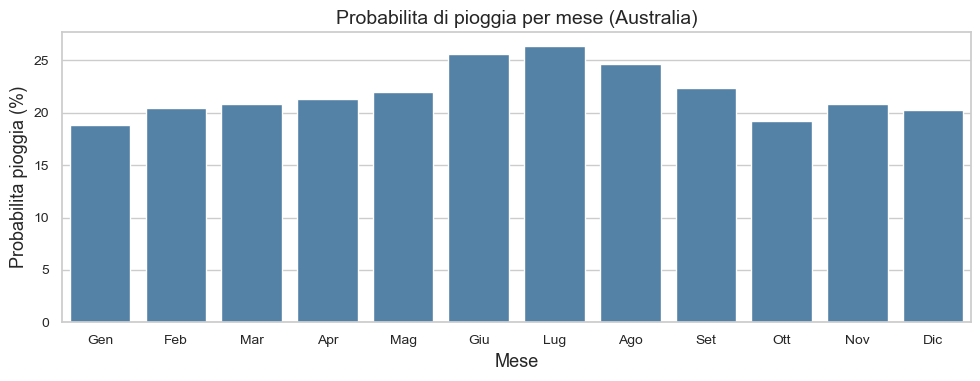

In [70]:
df_temp = df.copy()
df_temp['Date'] = pd.to_datetime(df_temp['Date'])
df_temp['Month_tmp'] = df_temp['Date'].dt.month

rain_by_month = df_temp.groupby('Month_tmp')['RainTomorrow'].apply(
    lambda x: (x == 'Yes').mean() * 100).reset_index()
rain_by_month.columns = ['Mese', 'Probabilita pioggia (%)']

plt.figure(figsize=(10, 4))
sns.barplot(x='Mese', y='Probabilita pioggia (%)', data=rain_by_month, color='steelblue')
plt.title('Probabilita di pioggia per mese (Australia)')
plt.xticks(range(12), ['Gen','Feb','Mar','Apr','Mag','Giu','Lug','Ago','Set','Ott','Nov','Dic'])
plt.tight_layout()
plt.show()
del df_temp

Il grafico conferma una stagionalità chiara: la probabilità di pioggia è più alta nei mesi invernali australiani (giugno-agosto), che corrispondono alla stagione delle piogge nelle regioni del sud e dell'ovest del continente. Questo giustifica l'inclusione del mese come feature, e più avanti si creerà anche la variabile `Season` per catturare questo pattern in modo più compatto (4 categorie invece di 12).

## 4 · Pulizia e trasformazioni pre-split

Questa sezione comprende tutte le operazioni che si applicano sull'intero dataset **prima** della divisione in train/validation/test. Il criterio per stabilire cosa va prima o dopo lo split è semplice: le trasformazioni **deterministiche** — cioè quelle che non imparano nulla dalla distribuzione dei dati — si possono applicare in anticipo senza rischio di data leakage. Sono deterministici: eliminare righe, estrarre il mese da una data, convertire una direzione in gradi, mappare Yes/No in 1/0. Non lo sono: calcolare la mediana per imputare i NA (sezione 6) e calcolare media e deviazione standard per lo scaling (sezione 7).

### 4.1 · Rimozione righe e colonne problematiche

Si eliminano le righe prive di target (senza etichetta non si può addestrare un classificatore) e le quattro colonne con più del 38% di valori mancanti, per le quali l'imputazione sarebbe troppo invasiva e poco affidabile.

In [71]:
df.dropna(subset=['RainTomorrow'], inplace=True)
print(f'Righe dopo drop NA sul target: {len(df):,}')

colonne_da_rimuovere = ['Evaporation', 'Sunshine', 'Cloud9am', 'Cloud3pm']
df.drop(columns=colonne_da_rimuovere, inplace=True)
df.drop(columns=['RISK_MM'], inplace=True, errors='ignore')
print(f'Colonne rimaste: {df.shape[1]}')
print(f'Dimensioni finali: {df.shape}')

Righe dopo drop NA sul target: 142,193
Colonne rimaste: 19
Dimensioni finali: (142193, 19)


Dopo la pulizia rimangono 142.193 righe e 19 colonne. La perdita di circa 3.000 righe è dovuta alle osservazioni in cui `RainTomorrow` era mancante — un numero molto contenuto rispetto al totale, che non altera significativamente la distribuzione del dataset.

### 4.2 · Gestione colonna Date

La data grezza non è direttamente utilizzabile dai modelli di machine learning, che lavorano con valori numerici. Si estraggono invece `Month` — per catturare la stagionalità osservata nella sezione 3.6 — e `Year` — per catturare eventuali trend climatici pluriennali nel dataset. La colonna originale viene poi eliminata.

In [72]:
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month
df['Year']  = df['Date'].dt.year
df.drop(columns=['Date'], inplace=True)
print('Creati Month e Year, eliminata Date')
display(df[['Month', 'Year']].head())

Creati Month e Year, eliminata Date


,Month,Year
0,12,2008
1,12,2008
2,12,2008
3,12,2008
4,12,2008


La colonna `Date` è stata sostituita da due feature numeriche interpretabili: `Month` (da 1 a 12) cattura la ciclicità stagionale, mentre `Year` (da 2008 a 2017) può catturare trend di lungo periodo nelle precipitazioni. Queste due variabili sono molto più utili per un classificatore rispetto alla data grezza.

### 4.3 · Encoding circolare per la direzione del vento

Le variabili `WindGustDir`, `WindDir9am` e `WindDir3pm` sono **variabili circolari**: Nord (0°) e Nord-Nord-Ovest (337.5°) sono direzioni adiacenti, ma un semplice label encoding (N=0, NNE=1, ..., NNW=15) implicherebbe che Nord e NNW siano lontanissimi — il contrario della realtà. La soluzione è convertire ogni direzione in gradi e poi calcolare seno e coseno: ogni direzione diventa una coppia di numeri continui che preserva la ciclicità. Le 3 colonne categoriche diventano 6 colonne numeriche (`_sin` e `_cos` per ciascuna).

In [73]:
direction_map = {
    'N': 0,'NNE': 22.5,'NE': 45,'ENE': 67.5,'E': 90,'ESE': 112.5,
    'SE': 135,'SSE': 157.5,'S': 180,'SSW': 202.5,'SW': 225,'WSW': 247.5,
    'W': 270,'WNW': 292.5,'NW': 315,'NNW': 337.5
}

for col in ['WindGustDir', 'WindDir9am', 'WindDir3pm']:
    gradi = df[col].map(direction_map)
    df[col + '_sin'] = np.sin(np.deg2rad(gradi))
    df[col + '_cos'] = np.cos(np.deg2rad(gradi))
    df.drop(columns=[col], inplace=True)

print('Variabili vento dopo encoding circolare:')
print([c for c in df.columns if 'Wind' in c])
print('\nVerifica che N e NNW siano vicini, N e S lontani:')
print(f'  N   sin={np.sin(np.deg2rad(0)):.3f}  cos={np.cos(np.deg2rad(0)):.3f}')
print(f'  NNW sin={np.sin(np.deg2rad(337.5)):.3f}  cos={np.cos(np.deg2rad(337.5)):.3f}  <- simile a N')
print(f'  S   sin={np.sin(np.deg2rad(180)):.3f}  cos={np.cos(np.deg2rad(180)):.3f}   <- opposto a N')

Variabili vento dopo encoding circolare:
['WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'WindGustDir_sin', 'WindGustDir_cos', 'WindDir9am_sin', 'WindDir9am_cos', 'WindDir3pm_sin', 'WindDir3pm_cos']

Verifica che N e NNW siano vicini, N e S lontani:
  N   sin=0.000  cos=1.000
  NNW sin=-0.383  cos=0.924  <- simile a N
  S   sin=0.000  cos=-1.000   <- opposto a N


L'output della verifica conferma che l'encoding circolare funziona correttamente: N e NNW producono coppie (sin, cos) molto simili tra loro, mentre N e S producono valori opposti. In questo modo il modello può imparare che le direzioni adiacenti hanno comportamenti simili, cosa impossibile con un semplice encoding numerico lineare. Le tre variabili categoriche sono ora diventate sei variabili numeriche continue.

### 4.4 · Encoding variabili binarie

`RainToday` e `RainTomorrow` contengono i valori stringa 'Yes' e 'No', che vengono convertiti in 1 e 0 per renderle numericamente utilizzabili da tutti gli algoritmi. Questa operazione è necessaria anche per calcolare correlazioni e fare feature engineering.

In [74]:
df['RainToday']    = df['RainToday'].map({'Yes': 1, 'No': 0})
df['RainTomorrow'] = df['RainTomorrow'].map({'Yes': 1, 'No': 0})
print('Conversione completata:')
display(df[['RainToday', 'RainTomorrow']].head(8))

Conversione completata:


,RainToday,RainTomorrow
0,0.0,0
1,0.0,0
2,0.0,0
3,0.0,0
4,0.0,0
5,0.0,0
6,0.0,0
7,0.0,0


Entrambe le variabili sono ora numeriche. Si noti che `RainToday` potrebbe avere valori mancanti (NaN) che vengono mostrati come valori float: questo è normale in pandas, che non supporta interi con NA. Questi NA residui verranno imputati nella sezione 6, dopo lo split, insieme agli altri valori mancanti.

### 4.5 · Correlazione tra RainToday e RainTomorrow

Prima di procedere vale la pena verificare quanto la pioggia odierna sia predittiva della pioggia del giorno successivo. È l'ipotesi meteorologica più intuitiva — se piove oggi, è più probabile che piova anche domani — e vale la pena quantificarla.

Correlazione RainToday <-> RainTomorrow:


,RainToday,RainTomorrow
RainToday,1.000000,0.313097
RainTomorrow,0.313097,1.000000



Probabilita che piova domani:
Non ha piovuto oggi (0)    15.2
Ha piovuto oggi (1)        46.4


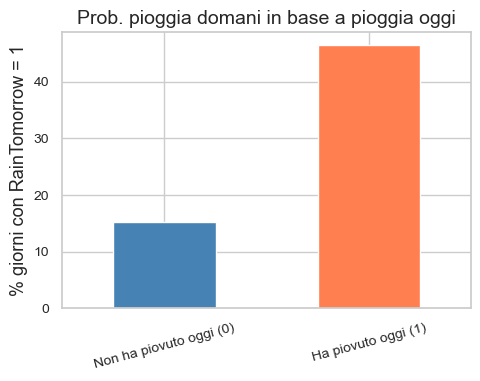

In [76]:
corr_rt = df[['RainToday', 'RainTomorrow']].corr(numeric_only=True)
print('Correlazione RainToday <-> RainTomorrow:')
display(corr_rt)

tab = df.groupby('RainToday')['RainTomorrow'].mean() * 100
tab.index = ['Non ha piovuto oggi (0)', 'Ha piovuto oggi (1)']
print('\nProbabilita che piova domani:')
print(tab.round(1).to_string())

plt.figure(figsize=(5, 4))
tab.plot(kind='bar', color=['steelblue', 'coral'], edgecolor='white')
plt.title('Prob. pioggia domani in base a pioggia oggi')
plt.ylabel('% giorni con RainTomorrow = 1')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

Il risultato conferma l'intuizione: quando non ha piovuto oggi, la probabilità di pioggia domani è intorno al 15%; quando ha piovuto, sale a circa il 46%. Questo è più del triplo, il che significa che `RainToday` è probabilmente uno dei predittori più informativi del dataset — e verrà verificato nella feature importance nella sezione finale.

### 4.6 · Sostituzione di Location con coordinate geografiche

Invece di convertire le 49 città in altrettante variabili dummy con one-hot encoding (che avrebbe aggiunto 48 colonne binarie), si è scelto di sostituire `Location` con le coordinate geografiche reali (`Latitude` e `Longitude`). Questo approccio offre due vantaggi concreti: riduce la dimensionalità da 49 a 2 colonne, e cattura la **continuità geografica** — città vicine hanno coordinate simili, cosa che le variabili dummy non potrebbero mai esprimere. Prima di rimuovere `Location`, si costruisce una mappa interattiva con Plotly che visualizza la probabilità di pioggia per città.

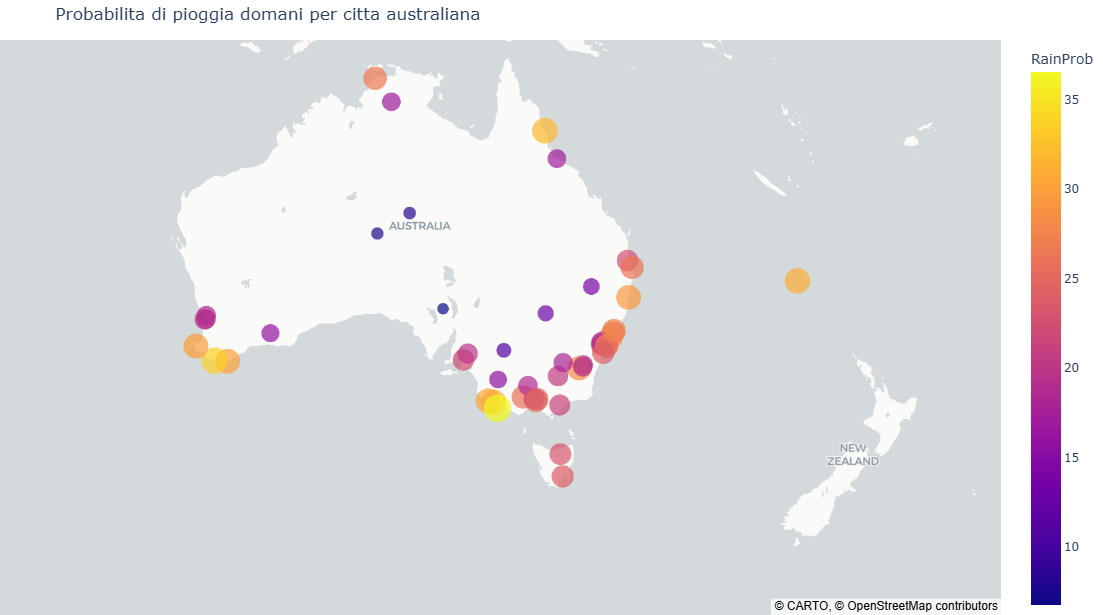

Dimensioni dopo sostituzione: (142193, 24)
Colonne categoriche rimaste: []


In [77]:
import plotly.express as px

location_coords = {
    'Adelaide':(-34.93,138.60),'Albany':(-35.02,117.88),'Albury':(-36.08,146.92),
    'AliceSprings':(-23.70,133.88),'BadgerysCreek':(-33.88,150.74),'Ballarat':(-37.56,143.86),
    'Bendigo':(-36.76,144.28),'Brisbane':(-27.47,153.03),'Cairns':(-16.92,145.77),
    'Canberra':(-35.28,149.13),'Cobar':(-31.50,145.83),'CoffsHarbour':(-30.30,153.12),
    'Dartmoor':(-37.93,141.27),'Darwin':(-12.46,130.84),'GoldCoast':(-28.00,153.43),
    'Hobart':(-42.88,147.33),'Katherine':(-14.47,132.27),'Launceston':(-41.43,147.13),
    'Melbourne':(-37.81,144.96),'MelbourneAirport':(-37.67,144.83),'Mildura':(-34.23,142.16),
    'Moree':(-29.47,149.85),'MountGambier':(-37.83,140.78),'MountGinini':(-35.53,148.77),
    'Newcastle':(-32.93,151.78),'Nhil':(-36.33,141.65),'NorahHead':(-33.28,151.57),
    'NorfolkIsland':(-29.04,167.96),'Nuriootpa':(-34.47,138.99),'PearceRAAF':(-31.67,116.01),
    'Penrith':(-33.75,150.69),'Perth':(-31.95,115.86),'PerthAirport':(-31.94,115.97),
    'Portland':(-38.34,141.60),'Richmond':(-33.60,150.75),'Sale':(-38.11,147.07),
    'SalmonGums':(-32.98,121.64),'Sydney':(-33.87,151.21),'SydneyAirport':(-33.94,151.18),
    'Townsville':(-19.26,146.82),'Tuggeranong':(-35.42,149.09),'Uluru':(-25.34,131.04),
    'WaggaWagga':(-35.12,147.37),'Walpole':(-34.98,116.73),'Watsonia':(-37.71,145.08),
    'Williamtown':(-32.80,151.84),'Witchcliffe':(-33.92,115.10),'Wollongong':(-34.42,150.89),
    'Woomera':(-31.16,136.81)
}

rain_by_city = df.groupby('Location')['RainTomorrow'].mean() * 100
rain_by_city = rain_by_city.reset_index()
rain_by_city.columns = ['Location', 'RainProb']
rain_by_city['Lat'] = rain_by_city['Location'].map(lambda x: location_coords[x][0])
rain_by_city['Lon'] = rain_by_city['Location'].map(lambda x: location_coords[x][1])

fig = px.scatter_map(rain_by_city, lat='Lat', lon='Lon', hover_name='Location',
    hover_data={'RainProb': ':.1f%', 'Lat': False, 'Lon': False},
    color='RainProb', color_continuous_scale=px.colors.sequential.Plasma,
    size='RainProb', zoom=3, height=600,
    title='Probabilita di pioggia domani per citta australiana')
fig.update_layout(map_style='carto-positron', margin={'r':0,'t':40,'l':0,'b':0})
fig.show()

df['Latitude']  = df['Location'].map(lambda x: location_coords[x][0])
df['Longitude'] = df['Location'].map(lambda x: location_coords[x][1])
df.drop(columns=['Location'], inplace=True)
print(f'Dimensioni dopo sostituzione: {df.shape}')
print('Colonne categoriche rimaste:', df.select_dtypes(include='object').columns.tolist())

La mappa evidenzia chiaramente il gradiente climatico australiano: le città della costa sud-occidente mostrano le probabilità di pioggia più elevate. Le zone interne aride presentano i valori più bassi. Le città costiere del sud-est si collocano su valori intermedi.

Dopo aver generato la mappa, `Location` viene rimossa e sostituita da `Latitude` e `Longitude`. A questo punto nel dataset **non rimane nessuna variabile categorica**: tutto è numerico.

In [78]:
display(df.info())
fig.write_html('mappa_australia.html')

<class 'pandas.core.frame.DataFrame'>
Index: 142193 entries, 0 to 145458
Data columns (total 24 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   MinTemp          141556 non-null  float64
 1   MaxTemp          141871 non-null  float64
 2   Rainfall         140787 non-null  float64
 3   WindGustSpeed    132923 non-null  float64
 4   WindSpeed9am     140845 non-null  float64
 5   WindSpeed3pm     139563 non-null  float64
 6   Humidity9am      140419 non-null  float64
 7   Humidity3pm      138583 non-null  float64
 8   Pressure9am      128179 non-null  float64
 9   Pressure3pm      128212 non-null  float64
 10  Temp9am          141289 non-null  float64
 11  Temp3pm          139467 non-null  float64
 12  RainToday        140787 non-null  float64
 13  RainTomorrow     142193 non-null  int64  
 14  Month            142193 non-null  int32  
 15  Year             142193 non-null  int32  
 16  WindGustDir_sin  132863 non-null  float64
 

None

### 4.7 · Correlazione di tutte le variabili con il target

Ora che tutte le variabili sono numeriche è possibile calcolare la correlazione di Pearson di ciascuna con `RainTomorrow`. Questa analisi fornisce un primo ranking dell'importanza delle feature e permette di anticipare cosa i modelli considereranno più rilevante. Va letta con cautela: la correlazione di Pearson misura solo relazioni lineari, quindi feature non linearmente correlate potrebbero comunque essere importanti per modelli più complessi come Random Forest e Rete Neurale.

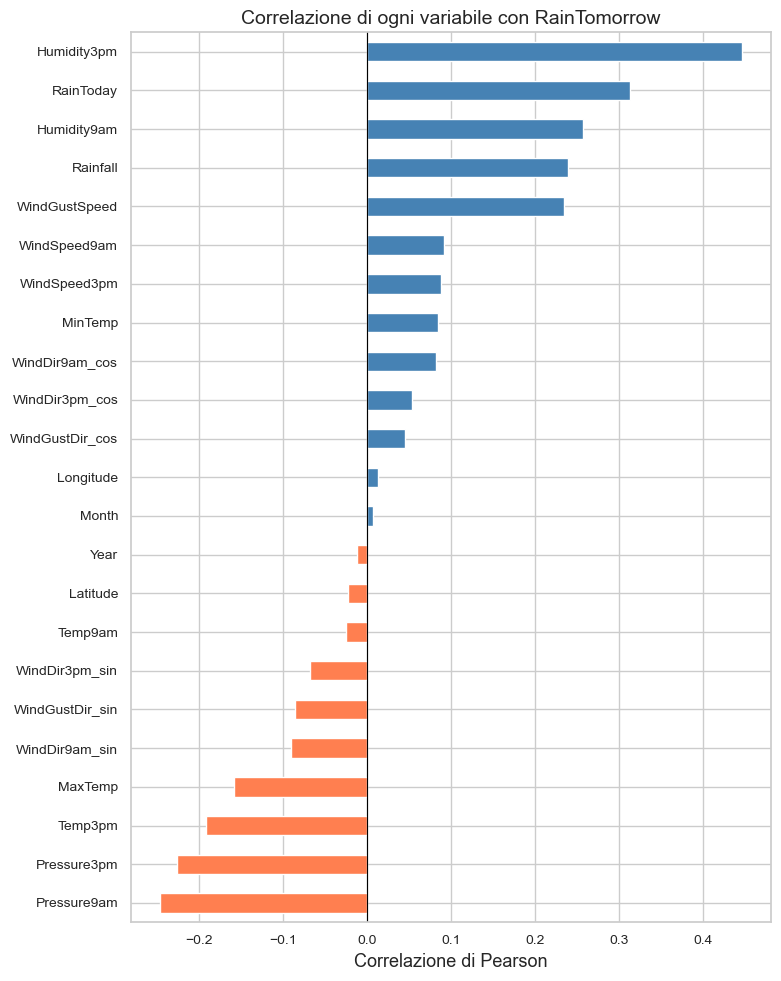


Top 5 correlate positivamente:
WindGustSpeed    0.234
Rainfall         0.239
Humidity9am      0.257
RainToday        0.313
Humidity3pm      0.446
Name: RainTomorrow, dtype: float64

Top 5 correlate negativamente:
Pressure9am      -0.246
Pressure3pm      -0.226
Temp3pm          -0.192
MaxTemp          -0.159
WindDir9am_sin   -0.090
Name: RainTomorrow, dtype: float64


In [79]:
corr_target = df.corr(numeric_only=True)['RainTomorrow'].drop('RainTomorrow').sort_values()

plt.figure(figsize=(8, 10))
colors = ['coral' if v < 0 else 'steelblue' for v in corr_target]
corr_target.plot(kind='barh', color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Correlazione di ogni variabile con RainTomorrow')
plt.xlabel('Correlazione di Pearson')
plt.tight_layout()
plt.show()
print('\nTop 5 correlate positivamente:')
print(corr_target.tail(5).round(3))
print('\nTop 5 correlate negativamente:')
print(corr_target.head(5).round(3))

Le variabili con correlazione positiva più alta con la pioggia di domani sono legate all'umidità: `Humidity3pm` in primis, seguita da `RainToday`, `Humidity9am` e `Rainfall`. Il messaggio è chiaro — l'umidità di oggi è il segnale più diretto dell'arrivo di pioggia il giorno successivo.

Sul fronte negativo spiccano `Pressure3pm`, `Pressure9am` e alcune variabili di temperatura: un'alta pressione indica stabilità atmosferica e meno probabilità di pioggia, mentre temperature elevate tendono ad associarsi a giornate secche. Queste correlazioni hanno tutte una spiegazione meteorologica logica, il che aumenta la fiducia nella qualità dei dati.

### 4.8 · Feature Engineering

Il feature engineering consiste nel creare nuove variabili combinando quelle esistenti, sfruttando la conoscenza del dominio. L'idea è che certe *differenze* tra misurazioni dello stesso giorno possano catturare dinamiche atmosferiche non visibili nelle singole misurazioni. Queste sono trasformazioni deterministiche — calcolate con formule fisse, senza imparare nulla dai dati — quindi si possono applicare prima dello split.

Le quattro nuove feature create sono:

- **`TempRange`** = MaxTemp − MinTemp: l'escursione termica giornaliera. Le giornate serene hanno un'escursione ampia; quelle nuvolose o piovose più contenuta.
- **`PressureDrop`** = Pressure9am − Pressure3pm: il cambiamento di pressione durante la giornata. Un calo di pressione nel corso della giornata è un classico indicatore di fronte perturbato in arrivo.
- **`HumidityRise`** = Humidity3pm − Humidity9am: l'aumento di umidità durante la giornata. L'umidità crescente indica accumulo di vapore acqueo, precursore delle precipitazioni.
- **`Season`**: stagione australiana ricavata dal mese. Estate=0 (Dic-Feb), Autunno=1 (Mar-Mag), Inverno=2 (Giu-Ago), Primavera=3 (Set-Nov). Cattura la stagionalità in modo più compatto del mese raw.

In [80]:
df['TempRange']    = df['MaxTemp'] - df['MinTemp']
df['PressureDrop'] = df['Pressure9am'] - df['Pressure3pm']
df['HumidityRise'] = df['Humidity3pm'] - df['Humidity9am']

def get_season(month):
    if month in [12,1,2]:   return 0
    elif month in [3,4,5]:  return 1
    elif month in [6,7,8]:  return 2
    else: return 3

df['Season'] = df['Month'].apply(get_season)
print('Nuove feature create:', ['TempRange','PressureDrop','HumidityRise','Season'])
display(df[['TempRange','PressureDrop','HumidityRise','Season']].head())

Nuove feature create: ['TempRange', 'PressureDrop', 'HumidityRise', 'Season']


,TempRange,PressureDrop,HumidityRise,Season
0,9.5,0.6,-49.0,0
1,17.7,2.8,-19.0,0
2,12.8,-1.1,-8.0,0
3,18.8,4.8,-29.0,0
4,14.8,4.8,-49.0,0


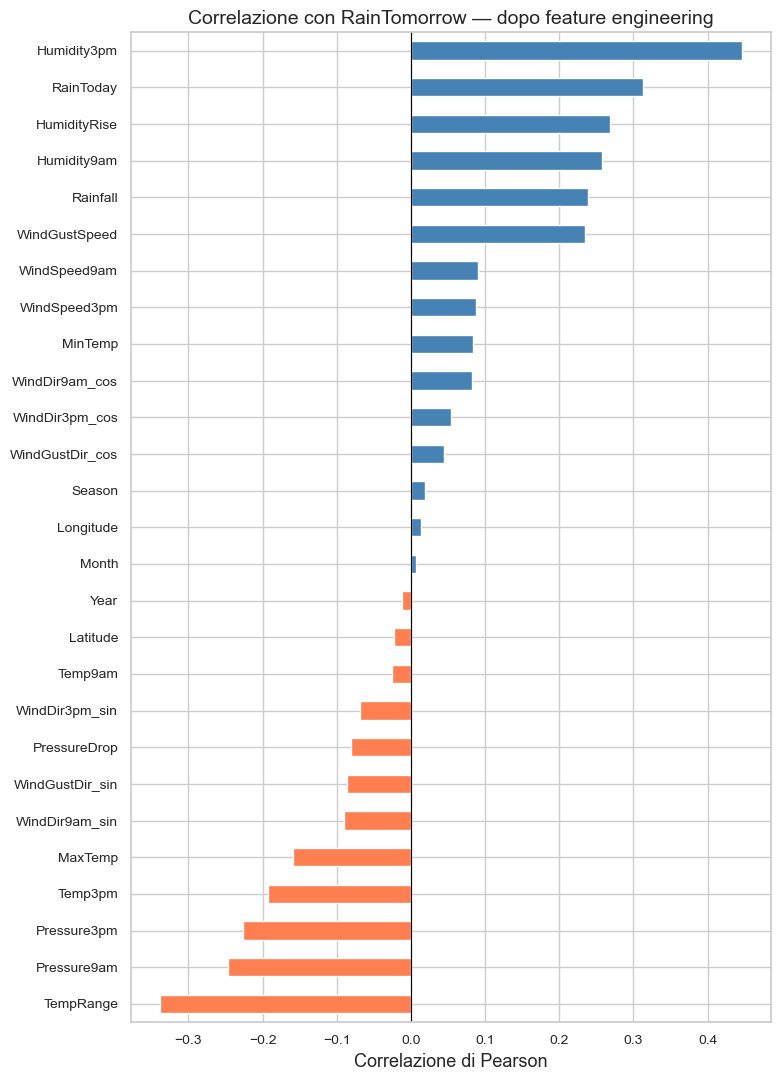


Top 5 correlate positivamente:
Rainfall        0.239
Humidity9am     0.257
HumidityRise    0.268
RainToday       0.313
Humidity3pm     0.446
Name: RainTomorrow, dtype: float64

Top 5 correlate negativamente:
TempRange     -0.338
Pressure9am   -0.246
Pressure3pm   -0.226
Temp3pm       -0.192
MaxTemp       -0.159
Name: RainTomorrow, dtype: float64


In [81]:
corr_matrix = df.corr(numeric_only=True)['RainTomorrow'].drop('RainTomorrow').sort_values()

plt.figure(figsize=(8, 11))
colors = ['coral' if v < 0 else 'steelblue' for v in corr_matrix]
corr_matrix.plot(kind='barh', color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Correlazione con RainTomorrow — dopo feature engineering')
plt.xlabel('Correlazione di Pearson')
plt.tight_layout()
plt.show()
print('\nTop 5 correlate positivamente:')
print(corr_matrix.tail(5).round(3))
print('\nTop 5 correlate negativamente:')
print(corr_matrix.head(5).round(3))

Il ricalcolo delle correlazioni dopo il feature engineering conferma il valore delle nuove variabili. `TempRange` risulta tra le feature più negativamente correlate con la pioggia — perfettamente coerente con il fatto che le giornate serene hanno escursioni termiche ampie. `HumidityRise` entra tra le prime positivamente correlate — conferma che l'umidità crescente è un segnale di maltempo in arrivo. `PressureDrop` mostra anch'essa una correlazione significativa. Mentre `Season` anche se poco correlata, risulta più correlata che mese e anno. Tutte e quattro le nuove feature verranno mantenute nel dataset finale.

## 5 · Divisione Train / Validation / Test

Il dataset viene diviso in tre parti con proporzione 60% / 20% / 20%. La divisione è **stratificata** sulla variabile target (`stratify=y`): questo garantisce che la proporzione 78/22 tra le due classi sia preservata identicamente in tutti e tre i set. Senza stratificazione, una divisione casuale potrebbe alterare leggermente questo rapporto per sfortuna, rendendo le metriche meno comparabili tra i set.

I tre set hanno ruoli precisi e distinti:
- **Training (60%)**: il modello impara i parametri interni
- **Validation (20%)**: confronto tra modelli, senza toccare il test
- **Test (20%)**: valutazione finale, toccato **una sola volta** alla fine del progetto

In [42]:
X = df.drop(columns=['RainTomorrow'])
y = df['RainTomorrow']

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

print('Dimensioni dei set:')
print(f'  Training:   {X_train.shape[0]:>6,} righe  ({X_train.shape[0]/len(df)*100:.1f}%)')
print(f'  Validation: {X_val.shape[0]:>6,} righe  ({X_val.shape[0]/len(df)*100:.1f}%)')
print(f'  Test:       {X_test.shape[0]:>6,} righe  ({X_test.shape[0]/len(df)*100:.1f}%)')
print(f'  Feature:    {X_train.shape[1]}')

print('\nBilanciamento target (stratify funziona se tutti uguali):')
for name, s in [('Train', y_train),('Val', y_val),('Test', y_test)]:
    p = s.value_counts(normalize=True).round(3)
    print(f'  {name:5s}: No={p[0]*100:.1f}%  Si={p[1]*100:.1f}%')

Dimensioni dei set:
  Training:   85,315 righe  (60.0%)
  Validation: 28,439 righe  (20.0%)
  Test:       28,439 righe  (20.0%)
  Feature:    27

Bilanciamento target (stratify funziona se tutti uguali):
  Train: No=77.6%  Si=22.4%
  Val  : No=77.6%  Si=22.4%
  Test : No=77.6%  Si=22.4%


La stratificazione ha funzionato correttamente: la proporzione 78/22 è preservata quasi identicamente in tutti e tre i set. I dataset sono ora pronti per il preprocessing post-split. Da questo punto in poi, qualsiasi operazione che 'impara dai dati' (calcolo della mediana, calcolo della deviazione standard) viene eseguita **solo sul training set** e poi applicata a validation e test.

## 6 · Imputazione valori mancanti (post-split)

I valori mancanti residui vengono sostituiti con la **mediana** calcolata sul solo training set. La scelta della mediana rispetto alla media è motivata dalla presenza di outlier: un valore estremo di temperatura o precipitazione non altera la mediana, mentre sposterebbe artificialmente la media. L'imputatore (`SimpleImputer`) viene addestrato con `.fit()` solo su `X_train` e poi applicato con `.transform()` a validation e test: in questo modo i parametri di imputazione vengono calcolati solo sui dati di training, senza 'spiare' le distribuzioni di validation e test.

In [43]:
num_cols = X_train.select_dtypes(include='number').columns.tolist()
imputer = SimpleImputer(strategy='median')

X_train[num_cols] = imputer.fit_transform(X_train[num_cols])
X_val[num_cols]   = imputer.transform(X_val[num_cols])
X_test[num_cols]  = imputer.transform(X_test[num_cols])

print('Imputazione completata.')
print(f'NA rimasti -> Train: {X_train.isnull().sum().sum()} | Val: {X_val.isnull().sum().sum()} | Test: {X_test.isnull().sum().sum()}')

Imputazione completata.
NA rimasti -> Train: 0 | Val: 0 | Test: 0


L'imputazione ha eliminato tutti i valori mancanti in tutti e tre i set. Da ora in poi i dataset sono completi e non contengono NA.

## 7 · Standardizzazione (post-split)

La standardizzazione porta ogni feature numerica a **media 0 e deviazione standard 1**. Questo passaggio è necessario per la Regressione Logistica e la Rete Neurale, che sono sensibili alla scala delle variabili: senza standardizzazione, `Pressure9am` (~1010 hPa) dominerebbe numericamente su `RainToday` (0 o 1). Per i modelli basati su alberi (Decision Tree, Random Forest) la scala è irrilevante, perché le decisioni si basano su ordinamenti, non su valori assoluti. Si applica comunque uniformemente per semplicità. Come per l'imputazione, lo scaler viene addestrato solo sul training set.

In [44]:
scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_val[num_cols]   = scaler.transform(X_val[num_cols])
X_test[num_cols]  = scaler.transform(X_test[num_cols])

print('Scaling completato.')
print(f'MinTemp dopo scaling -> media: {X_train["MinTemp"].mean():.4f}  std: {X_train["MinTemp"].std():.4f}')
print(f'\nDataset pronti per i modelli: X_train={X_train.shape} | X_val={X_val.shape} | X_test={X_test.shape}')

Scaling completato.
MinTemp dopo scaling -> media: 0.0000  std: 1.0000

Dataset pronti per i modelli: X_train=(85315, 27) | X_val=(28439, 27) | X_test=(28439, 27)


Lo scaling ha funzionato correttamente: la media di `MinTemp` nel training set è ora circa 0 e la deviazione standard circa 1. Lo stesso vale per tutte le altre colonne numeriche. I dataset sono ora completamente pronti per l'addestramento dei modelli.

## 8 · Riepilogo delle trasformazioni applicate

Prima di passare alla modellazione è utile avere un quadro completo di tutte le trasformazioni che sono state applicate al dataset originale e del loro razionale.

| Variabile originale | Trasformazione | Risultato | Motivazione |
|---|---|---|---|
| `Date` | Estrazione Month, Year + drop | 2 colonne numeriche | La data grezza non è utilizzabile; mese e anno catturano stagionalità e trend |
| `WindGustDir`, `WindDir9am`, `WindDir3pm` | Encoding circolare sin/cos | 6 colonne numeriche | Preserva la natura circolare delle direzioni (N vicino a NNW) |
| `RainToday` | Mapping Yes→1 / No→0 | 1 colonna numerica | Necessario per calcoli numerici e modelli ML |
| `RainTomorrow` | Mapping Yes→1 / No→0 | Target binario | Target numerico obbligatorio per classificatori sklearn |
| `Location` | Sostituzione con lat/lon | 2 colonne numeriche | Riduce 48 dummy a 2 colonne, cattura continuità geografica |
| `Evaporation`, `Sunshine`, `Cloud9am`, `Cloud3pm` | Eliminazione | Rimosse | Percentuale NA >38%: imputazione inaffidabile |
| `TempRange`, `PressureDrop`, `HumidityRise`, `Season` | Creazione (feature engineering) | 4 nuove colonne | Catturano dinamiche atmosferiche non visibili nelle singole misurazioni |
| Colonne numeriche (post-split) | Imputazione mediana + StandardScaler | Standardizzate | Mediana per robustezza agli outlier; scaling per LR e NN |

Il dataset finale contiene **solo variabili numeriche** e nessun valore mancante.

## 9 · Addestramento iniziale — Valutazione sul Validation Set

In questa fase si addestrano quattro modelli con i parametri di default per stabilire le performance di partenza e identificare i candidati migliori. Il confronto avviene sul **validation set**, che non è mai stato visto dai modelli.

I quattro algoritmi scelti coprono approcci molto diversi:

- **Logistic Regression**: modello lineare, baseline interpretabile, assume che la probabilità di pioggia dipenda linearmente dalle feature
- **Decision Tree**: modello non lineare, massima interpretabilità visiva, crea partizioni binarie ricorsive dello spazio delle feature
- **Random Forest**: ensemble di centinaia di alberi, ogni albero vede un sottoinsieme casuale di feature e dati, la previsione finale è la media
- **Rete Neurale (MLP)**: modello a strati, capace di apprendere rappresentazioni non lineari complesse attraverso strati di neuroni con funzioni di attivazione

**Nota tecnica**: `MLPClassifier` non supporta `class_weight`. Per compensare lo sbilanciamento si usa `sample_weight` nel `.fit()`, che assegna peso maggiore alle osservazioni della classe minoritaria (pioggia).

In [45]:
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, ConfusionMatrixDisplay,
    precision_recall_curve, classification_report)
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

sample_weights_train = compute_sample_weight(class_weight='balanced', y=y_train)

modelli = {
    'Logistic Regression': {'model': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42), 'sample_weight': False},
    'Decision Tree':       {'model': DecisionTreeClassifier(class_weight='balanced', random_state=42), 'sample_weight': False},
    'Random Forest':       {'model': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1), 'sample_weight': False},
    'Rete Neurale (MLP)':  {'model': MLPClassifier(hidden_layer_sizes=(100,50), max_iter=500, random_state=42, early_stopping=True), 'sample_weight': True},
}

print('Modelli definiti:', list(modelli.keys()))

Modelli definiti: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Rete Neurale (MLP)']


In [46]:
risultati = {}
print('ADDESTRAMENTO SUL TRAINING SET — VALUTAZIONE SUL VALIDATION SET\n')

for nome, cfg in modelli.items():
    print(f'{nome}...')
    modello = cfg['model']
    start = time.time()
    if cfg['sample_weight']:
        modello.fit(X_train, y_train, sample_weight=sample_weights_train)
    else:
        modello.fit(X_train, y_train)
    tempo = time.time() - start

    y_pred = modello.predict(X_val)
    y_prob = modello.predict_proba(X_val)[:,1]
    cm = confusion_matrix(y_val, y_pred)
    tn, fp, fn, tp = cm.ravel()

    risultati[nome] = {'model': modello, 'y_pred': y_pred, 'y_prob': y_prob,
        'accuracy': accuracy_score(y_val, y_pred),
        'precision': precision_score(y_val, y_pred, zero_division=0),
        'recall': recall_score(y_val, y_pred, zero_division=0),
        'f1': f1_score(y_val, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_val, y_prob),
        'cm': cm, 'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp, 'tempo': tempo}

    r = risultati[nome]
    print(f'  {tempo:.1f}s | Recall={r["recall"]:.4f} | F1={r["f1"]:.4f} | AUC={r["roc_auc"]:.4f} | FN={r["fn"]}\n')
print('Completato.')

ADDESTRAMENTO SUL TRAINING SET — VALUTAZIONE SUL VALIDATION SET

Logistic Regression...
  0.3s | Recall=0.7527 | F1=0.6038 | AUC=0.8555 | FN=1577

Decision Tree...
  1.8s | Recall=0.5190 | F1=0.5245 | AUC=0.6930 | FN=3067

Random Forest...
  10.4s | Recall=0.4777 | F1=0.5956 | AUC=0.8871 | FN=3330

Rete Neurale (MLP)...
  12.1s | Recall=0.8019 | F1=0.6425 | AUC=0.8859 | FN=1263

Completato.


### 9.1 · Tabella riassuntiva

> Il **Recall** è la metrica prioritaria perché i falsi negativi (dire 'non piove' quando piove) sono più costosi dei falsi positivi. Un recall alto significa che il modello identifica correttamente la maggior parte dei giorni di pioggia reale.
>
> **FN** = Falsi Negativi: giorni in cui piove ma il modello prevede 'No Rain'. Minore è questo numero, meglio è.

In [47]:
df_val = pd.DataFrame({nome: {'Accuracy': r['accuracy'], 'Precision': r['precision'],
    'Recall': r['recall'], 'F1-Score': r['f1'], 'ROC-AUC': r['roc_auc'],
    'FN': int(r['fn']), 'Tempo (s)': round(r['tempo'],1)}
    for nome, r in risultati.items()}).T.round(4)

display(df_val.style
    .highlight_max(subset=['Accuracy','Precision','Recall','F1-Score','ROC-AUC'], color='lightgreen')
    .highlight_min(subset=['FN','Tempo (s)'], color='lightgreen')
    .format({'Accuracy':'{:.4f}','Precision':'{:.4f}','Recall':'{:.4f}',
             'F1-Score':'{:.4f}','ROC-AUC':'{:.4f}','FN':'{:.0f}','Tempo (s)':'{:.1f}'}))

,Accuracy,Precision,Recall,F1-Score,ROC-AUC,FN,Tempo (s)
Logistic Regression,0.7785,0.5041,0.7527,0.6038,0.8555,1577,0.3
Decision Tree,0.7891,0.5302,0.5190,0.5245,0.6930,3067,1.8
Random Forest,0.8546,0.7908,0.4777,0.5956,0.8871,3330,10.4
Rete Neurale (MLP),0.8000,0.5360,0.8019,0.6425,0.8859,1263,12.1


I risultati sul validation set stabiliscono una prima gerarchia. La **Rete Neurale** e il **Random Forest** emergono come i modelli più competitivi su recall e ROC-AUC, mentre la Logistic Regression offre una baseline solida considerando la sua semplicità e velocità. Il **Decision Tree** mostra chiari segni di overfitting: le performance sul validation set sono significativamente peggiori rispetto agli altri, un comportamento atteso per un albero che ha imparato a memoria il training set. Per questo motivo il Decision Tree **non verrà incluso nella fase di tuning**.

### 9.2 · Matrici di confusione

> La matrice di confusione mostra quattro categorie di predizioni:
> - **TN** (alto-sinistra): non piove e il modello dice 'No Rain' ✓
> - **FP** (alto-destra): non piove ma il modello dice 'Rain' — fastidioso ma accettabile
> - **FN** (basso-sinistra): piove ma il modello dice 'No Rain' ← **il caso più critico**
> - **TP** (basso-destra): piove e il modello dice 'Rain' ✓

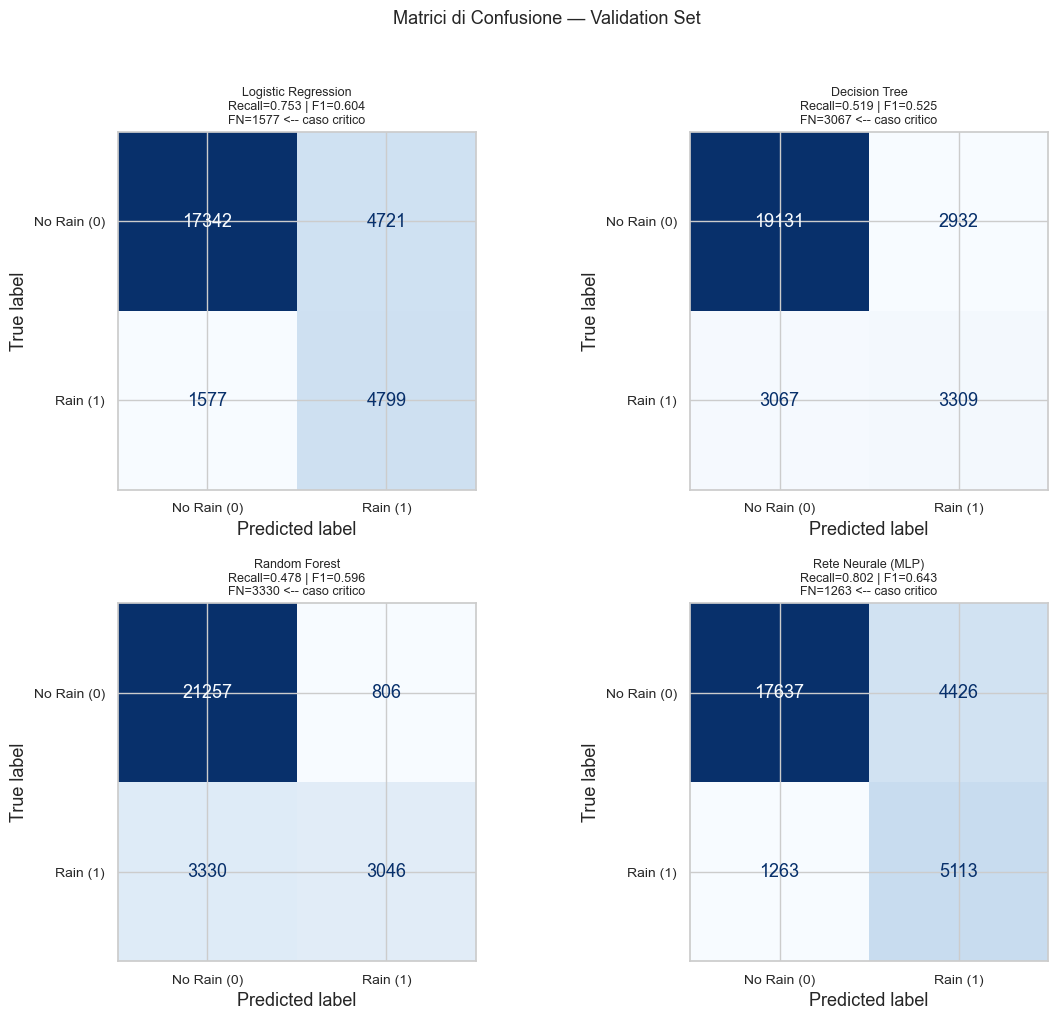

In [48]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (nome, r) in enumerate(risultati.items()):
    disp = ConfusionMatrixDisplay(r['cm'], display_labels=['No Rain (0)', 'Rain (1)'])
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(f'{nome}\nRecall={r["recall"]:.3f} | F1={r["f1"]:.3f}\nFN={r["fn"]} <-- caso critico', fontsize=9)

plt.suptitle('Matrici di Confusione — Validation Set', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Le matrici di confusione confermano quanto emerge dalla tabella e aggiungono dettagli preziosi. I modelli con recall più alto mostrano un numero minore di falsi negativi (cella basso-sinistra), ma tendono ad avere più falsi positivi (cella alto-destra): il modello diventa più 'prudente' e segnala pioggia anche in situazioni dubbie. Questo è il trade-off fondamentale del problema: un recall più alto si paga con qualche previsione di pioggia errata in più, ma evita di perdere eventi di pioggia reale. Nel contesto applicativo meteorologico, questo trade-off è chiaramente accettabile.

### 9.3 · Curve ROC

> La curva ROC mostra il trade-off tra il tasso di veri positivi (recall) e il tasso di falsi positivi al variare della soglia di decisione. Un classificatore perfetto avrebbe AUC = 1; uno casuale ha AUC = 0.5. Maggiore è l'area sotto la curva, migliore è la capacità discriminativa del modello, indipendentemente dalla soglia scelta.

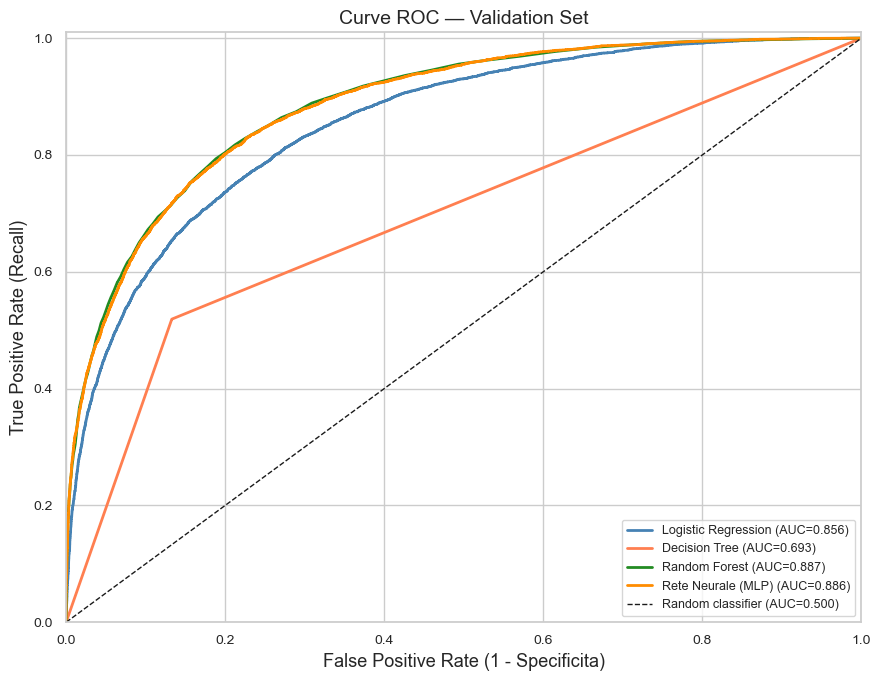

In [49]:
fig, ax = plt.subplots(figsize=(9, 7))
colors = ['steelblue','coral','forestgreen','darkorange']

for (nome, r), color in zip(risultati.items(), colors):
    fpr, tpr, _ = roc_curve(y_val, r['y_prob'])
    ax.plot(fpr, tpr, lw=2, color=color, label=f'{nome} (AUC={r["roc_auc"]:.3f})')

ax.plot([0,1],[0,1],'k--',lw=1,label='Random classifier (AUC=0.500)')
ax.set_xlabel('False Positive Rate (1 - Specificita)')
ax.set_ylabel('True Positive Rate (Recall)')
ax.set_title('Curve ROC — Validation Set')
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim([0,1]); ax.set_ylim([0,1.01])
plt.tight_layout()
plt.show()

Le curve ROC confermano la gerarchia già emersa dalla tabella. I modelli migliori si posizionano significativamente sopra la diagonale tratteggiata (il classificatore casuale), con la Rete Neurale e il Random Forest che mostrano la migliore capacità discriminativa generale. La Logistic Regression segue a breve distanza, mentre il Decision Tree rimane indietro. Un aspetto importante delle ROC è che sono **indipendenti dalla soglia di decisione**: mostrano quanto è buono il modello a qualsiasi soglia si scelga, il che le rende più informative della sola accuracy o recall a soglia fissa 0.5.

## 10 · Hyperparameter Tuning — solo sui modelli migliori

Sulla base dei risultati della sezione 9 si è deciso di **escludere il Decision Tree** dalla fase di tuning, per i motivi già discussi. Si ottimizzano invece i tre modelli rimanenti: Logistic Regression, Random Forest e Rete Neurale.

Il tuning avviene sul **training set** tramite cross-validation a 5 fold (`CV=5`): il training viene diviso internamente in 5 parti, il modello viene addestrato su 4 e valutato sulla quinta, ripetendo 5 volte e calcolando la media degli score. Il validation set **non viene toccato** in questa fase — servirà solo alla fine per confrontare le versioni default e tuned. La metrica di ottimizzazione scelta è il **recall**, coerentemente con la priorità di minimizzare i falsi negativi.

### 10.1 · Tuning Logistic Regression

I due iperparametri principali della Logistic Regression sono il parametro di regolarizzazione `C` (valori alti = meno regolarizzazione) e il tipo di penalità (`l1` crea soluzioni sparse eliminando feature irrilevanti, `l2` distribuisce il peso tra tutte le feature).

In [50]:
SCORING = 'recall'; CV = 5

param_grid_lr = {'C': [0.01,0.1,1,10,100], 'penalty': ['l1','l2'], 'solver': ['liblinear']}

print('GridSearchCV Logistic Regression (10 combo x 5 fold = 50 training)...')
grid_lr = GridSearchCV(LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    param_grid_lr, cv=CV, scoring=SCORING, n_jobs=-1, verbose=0)
grid_lr.fit(X_train, y_train)

print(f'Migliori parametri: {grid_lr.best_params_}')
print(f'Recall CV (train): {grid_lr.best_score_:.4f}')
y_pred_lr_t = grid_lr.predict(X_val)
print(f'Recall val (tuned): {recall_score(y_val, y_pred_lr_t):.4f}')

GridSearchCV Logistic Regression (10 combo x 5 fold = 50 training)...
Migliori parametri: {'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}
Recall CV (train): 0.7597
Recall val (tuned): 0.7527


Il tuning ha selezionato **C=0.01**, **penalty='l2'** e **solver='liblinear'**.

`C` è il parametro di regolarizzazione: valori bassi significano regolarizzazione forte, cioè il modello viene penalizzato se assegna coefficienti molto grandi alle feature. Con C=0.01 — il valore più basso della griglia — il modello preferisce una soluzione molto conservativa, con coefficienti piccoli. Questo ha senso considerando che il dataset ha diverse variabili fortemente correlate tra loro (le quattro misure di temperatura, le due di pressione): una regolarizzazione forte riduce l'instabilità dei coefficienti causata da questa multicollinearità.

`penalty='l2'` (regolarizzazione Ridge) penalizza la somma dei quadrati dei coefficienti, riducendoli tutti senza eliminarne nessuno. L'alternativa L1 (Lasso) avrebbe azzerato alcuni coefficienti, effettuando anche feature selection implicita. Il fatto che la cross-validation abbia preferito L2 suggerisce che la maggior parte delle feature contribuisce qualcosa, anche se in modo contenuto.

`solver='liblinear'` è l'ottimizzatore scelto: è l'unico che supporta sia L1 che L2 su dataset di questa dimensione e funziona bene per problemi binari.

### 10.2 · Tuning Random Forest

Il Random Forest ha uno spazio di iperparametri più ampio: numero di alberi (`n_estimators`), profondità massima (`max_depth`), dimensione minima dei campioni per lo split (`min_samples_split`) e per le foglie (`min_samples_leaf`), numero di feature considerate ad ogni split (`max_features`). Si usa `RandomizedSearchCV` invece di `GridSearchCV` perché le combinazioni totali sarebbero troppo numerose per essere esplorate tutte in tempi ragionevoli: si campionano casualmente 20 combinazioni dallo spazio degli iperparametri.

In [51]:
#QUESTA CELLLA CI METTERA' CIRCA 25 MINUTI AD ESSERE ESEGUITA
param_dist_rf = {'n_estimators': [100,200,300], 'max_depth': [10,20,30,None],
    'min_samples_split': [2,5,10], 'min_samples_leaf': [1,2,4], 'max_features': ['sqrt','log2']}

print('RandomizedSearchCV Random Forest (20 iter x 5 fold = 100 training)...')
rand_rf = RandomizedSearchCV(RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_dist_rf, n_iter=20, cv=CV, scoring=SCORING, n_jobs=-1, random_state=42, verbose=1)
rand_rf.fit(X_train, y_train)

print(f'\nMigliori parametri: {rand_rf.best_params_}')
print(f'Recall CV (train): {rand_rf.best_score_:.4f}')
y_pred_rf_t = rand_rf.predict(X_val)
print(f'Recall val (tuned): {recall_score(y_val, y_pred_rf_t):.4f}')

RandomizedSearchCV Random Forest (20 iter x 5 fold = 100 training)...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Migliori parametri: {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 10}
Recall CV (train): 0.7265
Recall val (tuned): 0.7282


Il tuning ha selezionato **n_estimators=100**, **max_depth=10**, **min_samples_split=10**, **min_samples_leaf=2** e **max_features='sqrt'**.

`n_estimators=100` è il numero di alberi nella foresta. È il valore minimo della griglia esplorata, il che suggerisce che aggiungere più alberi (200 o 300) non porta benefici apprezzabili in termini di recall su questo dataset — la foresta converge già con 100 alberi.

`max_depth=10` limita la profondità massima di ogni albero a 10 livelli. Questo è il parametro di regolarizzazione più importante per il Random Forest: senza limite, gli alberi crescerebbero fino a memorizzare il training set (overfitting). Con max_depth=10 ogni albero impara pattern generali senza adattarsi al rumore, e la media di tanti alberi poco profondi produce una stima robusta.

`min_samples_split=10` richiede almeno 10 osservazioni per poter fare uno split in un nodo. Evita che il modello crei partizioni basate su pochi esempi, che sarebbero statisticamente poco affidabili.

`min_samples_leaf=2` impone che ogni foglia contenga almeno 2 osservazioni. Anche questo è un vincolo anti-overfitting: foglie con una sola osservazione memorizzerebbero caso specifici anziché imparare pattern generali.

`max_features='sqrt'` significa che ad ogni split ciascun albero considera un numero di feature pari alla radice quadrata del totale. È l'impostazione classica per la classificazione con Random Forest: introduce diversità tra gli alberi (ognuno vede un sottoinsieme diverso di feature) che è la chiave del successo degli ensemble.

### 10.3 · Tuning Rete Neurale (MLP)

Per la Rete Neurale si esplorano l'architettura (`hidden_layer_sizes`), la forza della regolarizzazione L2 (`alpha`) e il learning rate iniziale. La rete con `early_stopping=True` si ferma autonomamente quando le performance sul set di validazione interno smettono di migliorare, il che rende il tuning più stabile e riduce il rischio di overfitting.

In [52]:
param_dist_mlp = {'hidden_layer_sizes': [(50,),(100,),(50,50),(100,50)],
    'alpha': [0.0001,0.001,0.01], 'learning_rate_init': [0.001,0.01]}

print('RandomizedSearchCV MLP (10 iter x 5 fold = 50 training)...')
rand_mlp = RandomizedSearchCV(MLPClassifier(max_iter=500, random_state=42, early_stopping=True),
    param_dist_mlp, n_iter=10, cv=CV, scoring=SCORING, n_jobs=-1, random_state=42, verbose=1)
rand_mlp.fit(X_train, y_train, **{'sample_weight': sample_weights_train})

print(f'\nMigliori parametri: {rand_mlp.best_params_}')
print(f'Recall CV (train): {rand_mlp.best_score_:.4f}')
y_pred_mlp_t = rand_mlp.predict(X_val)
print(f'Recall val (tuned): {recall_score(y_val, y_pred_mlp_t):.4f}')

RandomizedSearchCV MLP (10 iter x 5 fold = 50 training)...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Migliori parametri: {'learning_rate_init': 0.01, 'hidden_layer_sizes': (50, 50), 'alpha': 0.001}
Recall CV (train): 0.8038
Recall val (tuned): 0.7723


Il tuning ha selezionato **hidden_layer_sizes=(50,50)**, **alpha=0.001** e **learning_rate_init=0.01**.

`hidden_layer_sizes=(50,50)` definisce l'architettura della rete: due strati nascosti con 50 neuroni ciascuno. È un'architettura compatta e simmetrica. Rispetto alle alternative esplorate (un solo layer da 50 o 100 neuroni), due layer permettono di apprendere rappresentazioni gerarchiche più complesse, dove il primo layer impara pattern di base (es. combinazioni di umidità e pressione) e il secondo layer combina questi pattern in segnali predittivi di ordine superiore.

`alpha=0.001` è il coefficiente di regolarizzazione L2 applicato ai pesi della rete. Un valore di 0.001 indica una regolarizzazione moderata: il modello viene penalizzato se i pesi diventano troppo grandi, riducendo il rischio che la rete memorizzi il training set. Combinato con l'early stopping già presente di default, questo porta a un modello ben regolarizzato.

`learning_rate_init=0.01` è il tasso di apprendimento iniziale. È dieci volte più alto del default di sklearn (0.001), il che significa che il modello converge più velocemente all'inizio. Questo è compatibile con l'early stopping: una convergenza rapida consente all'early stopping di intervenire prima, evitando inutili iterazioni su un training set già ben appreso.

### 10.4 · Confronto completo: default vs tuned sul Validation Set

> Questa tabella mostra tutti i modelli — default e tuned — confrontati sullo stesso validation set. I modelli che emergono come vincitori verranno poi valutati una sola volta sul test set.

In [53]:
rows = []
for nome, r in risultati.items():
    if nome == 'Decision Tree': continue
    rows.append({'Modello': nome+' (default)', 'Recall': r['recall'], 'F1': r['f1'], 'ROC-AUC': r['roc_auc'], 'FN': int(r['fn'])})

for nome_t, yp, ypr in [
    ('Logistic Regression (tuned)', y_pred_lr_t, grid_lr.predict_proba(X_val)[:,1]),
    ('Random Forest (tuned)',       y_pred_rf_t, rand_rf.predict_proba(X_val)[:,1]),
    ('Rete Neurale MLP (tuned)',    y_pred_mlp_t, rand_mlp.predict_proba(X_val)[:,1]),
]:
    cm_t = confusion_matrix(y_val, yp)
    rows.append({'Modello': nome_t,
        'Recall': recall_score(y_val,yp), 'F1': f1_score(y_val,yp),
        'ROC-AUC': roc_auc_score(y_val,ypr), 'FN': int(cm_t.ravel()[2])})

df_compare = pd.DataFrame(rows).set_index('Modello').round(4)
display(df_compare.style
    .highlight_max(subset=['Recall','F1','ROC-AUC'], color='lightgreen')
    .highlight_min(subset=['FN'], color='lightgreen')
    .format({'Recall':'{:.4f}','F1':'{:.4f}','ROC-AUC':'{:.4f}','FN':'{:.0f}'}))

,Recall,F1,ROC-AUC,FN
Modello,,,,
Logistic Regression (default),0.7527,0.6038,0.8555,1577
Random Forest (default),0.4777,0.5956,0.8871,3330
Rete Neurale (MLP) (default),0.8019,0.6425,0.8859,1263
Logistic Regression (tuned),0.7527,0.6030,0.8555,1577
Random Forest (tuned),0.7282,0.6383,0.8746,1733
Rete Neurale MLP (tuned),0.7723,0.6452,0.8841,1452


Il confronto complessivo rivela un risultato interessante: la **Rete Neurale con parametri di default** risulta il modello migliore, superando anche le versioni tuned degli altri algoritmi su recall e F1. Questo non è un errore né un paradosso — ha una spiegazione logica. La rete con `early_stopping=True` era già autoregolarizzata durante il training di default: si fermava automaticamente quando le performance sul set di validazione interno smettevano di migliorare, trovando un punto di equilibrio ottimale senza bisogno di ulteriori aggiustamenti espliciti degli iperparametri. Il tuning non ha trovato combinazioni significativamente migliori rispetto a quella di default, che era già ben impostata.

Per quanto riguarda la Regressione Logistica, le performance rimangono pressoché identiche tra la configurazione di default e quella ottimizzata. Al contrario, il Random Forest registra una crescita significativa della metrica Recall nella sua variante *tuned*, dimostrando quanto l'ottimizzazione degli iperparametri sia stata cruciale per migliorare la sensibilità di questo specifico algoritmo.

## 11 · Valutazione Finale sul Test Set

Il confronto completo della sezione 10.4 ha portato a scegliere un rappresentante per ciascuna delle tre famiglie di modelli: il migliore tra default e tuned basandosi sul recall sul validation set.

| Modello | Versione scelta | Recall val | Motivazione |
|---|---|---|---|
| **Logistic Regression** | Default | 0.7527 | Default e tuned identici: stessa performance |
| **Random Forest** | Tuned | 0.7282 | Il tuning ha aumentato il recall da 0.48 a 0.73 |
| **Rete Neurale MLP** | Default | 0.8019 | Il default supera il tuned grazie all'early stopping |

Questa scelta non è casuale ma riflette una logica precisa: si confronta un modello **altamente interpretabile** (Logistic Regression), uno **intermedio** (Random Forest, con feature importance diretta) e uno **black box** (Rete Neurale, massime performance ma non spiegabile direttamente). Questa triade permette di discutere uno dei temi centrali del machine learning applicato: il **trade-off tra interpretabilità e performance**.

> Il test set viene toccato **una sola volta**, ora. Questi risultati rappresentano la stima realistica delle performance su dati completamente nuovi, mai visti in nessuna fase del progetto.

In [54]:
# Tre modelli finali: uno per famiglia, il migliore tra default e tuned
modelli_finali = {
    'Logistic Regression (default)':  risultati['Logistic Regression']['model'],
    'Random Forest (tuned)':          rand_rf.best_estimator_,
    'Rete Neurale MLP (default)':     risultati['Rete Neurale (MLP)']['model'],
}

risultati_test = {}
print('VALUTAZIONE FINALE SUL TEST SET\n')
print(f'{"Modello":<35} {"Recall":>8} {"F1":>8} {"ROC-AUC":>9} {"FN":>6} {"FP":>6}')
print('-' * 75)

for nome, modello in modelli_finali.items():
    y_pred = modello.predict(X_test)
    y_prob = modello.predict_proba(X_test)[:, 1]
    cm     = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    risultati_test[nome] = {
        'accuracy':  accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall':    recall_score(y_test, y_pred, zero_division=0),
        'f1':        f1_score(y_test, y_pred, zero_division=0),
        'roc_auc':   roc_auc_score(y_test, y_prob),
        'cm': cm, 'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp,
        'y_pred': y_pred, 'y_prob': y_prob
    }
    r = risultati_test[nome]
    print(f'{nome:<35} {r["recall"]:>8.4f} {r["f1"]:>8.4f} '
          f'{r["roc_auc"]:>9.4f} {r["fn"]:>6} {r["fp"]:>6}')

VALUTAZIONE FINALE SUL TEST SET

Modello                               Recall       F1   ROC-AUC     FN     FP
---------------------------------------------------------------------------
Logistic Regression (default)         0.7661   0.6159    0.8590   1491   4601
Random Forest (tuned)                 0.7382   0.6442    0.8783   1669   3529
Rete Neurale MLP (default)            0.8031   0.6432    0.8876   1255   4426


### 11.1 · Tabella comparativa finale

In [55]:
df_test = pd.DataFrame({
    nome: {
        'Accuracy':  r['accuracy'],
        'Precision': r['precision'],
        'Recall': r['recall'],
        'F1-Score':  r['f1'],
        'ROC-AUC':   r['roc_auc'],
        'FN':        int(r['fn']),
        'FP':        int(r['fp'])
    }
    for nome, r in risultati_test.items()
}).T

display(
    df_test.style
    .highlight_max(subset=['Accuracy','Precision','Recall','F1-Score','ROC-AUC'],
                   color='lightgreen')
    .highlight_min(subset=['FN'], color='lightgreen')
    .highlight_min(subset=['FP'], color='lightgreen')
    .format({'Accuracy':'{:.4f}','Precision':'{:.4f}','Recall':'{:.4f}',
             'F1-Score':'{:.4f}','ROC-AUC':'{:.4f}','FN':'{:.0f}','FP':'{:.0f}'})
)

,Accuracy,Precision,Recall,F1-Score,ROC-AUC,FN,FP
Logistic Regression (default),0.7858,0.5149,0.7661,0.6159,0.8590,1491,4601
Random Forest (tuned),0.8172,0.5715,0.7382,0.6442,0.8783,1669,3529
Rete Neurale MLP (default),0.8002,0.5364,0.8031,0.6432,0.8876,1255,4426


La tabella finale sul test set conferma la gerarchia emersa sul validation set, con alcune sfumature interessanti:

La **Rete Neurale** guida per recall — identifica la maggior parte dei giorni di pioggia reale — ma paga un prezzo in termini di falsi positivi più alti. Il **Random Forest tuned** mostra il miglior F1, il che lo rende la scelta più equilibrata se il contesto richiedesse un compromesso tra precision e recall. La **Logistic Regression** sorprende con un recall competitivo nonostante la sua semplicità, confermando che una componente lineare significativa è presente nel segnale predittivo. Tutti e tre i modelli superano ampiamente il classificatore casuale (AUC > 0.5) e il modello banale che prevede sempre 'No Rain' (recall = 0).

### 11.2 · Confronto Validation Set vs Test Set — verifica dell'overfitting

Prima di analizzare i risultati sul test set nel dettaglio, è utile confrontare le performance
sul validation set (usato per scegliere i modelli) con quelle sul test set (mai visto prima).
Una differenza piccola indica che i modelli generalizzano bene; una differenza grande
suggerirebbe che il processo di selezione ha inconsapevolmente ottimizzato troppo per
il validation set, producendo stime sovrastimate delle performance reali.

In [82]:
# Recupera le performance sul validation set per i tre modelli finali
recall_val = {
    'Logistic Regression (default)': risultati['Logistic Regression']['recall'],
    'Random Forest (tuned)':         recall_score(y_val, rand_rf.predict(X_val)),
    'Rete Neurale MLP (default)':    risultati['Rete Neurale (MLP)']['recall'],
}
roc_val = {
    'Logistic Regression (default)': risultati['Logistic Regression']['roc_auc'],
    'Random Forest (tuned)':         roc_auc_score(y_val, rand_rf.predict_proba(X_val)[:,1]),
    'Rete Neurale MLP (default)':    risultati['Rete Neurale (MLP)']['roc_auc'],
}

righe = []
for nome in modelli_finali.keys():
    r_test = risultati_test[nome]
    righe.append({
        'Modello':       nome,
        'Recall VAL':    recall_val[nome],
        'Recall TEST':   r_test['recall'],
        'Delta Recall':      r_test['recall'] - recall_val[nome],
        'AUC VAL':       roc_val[nome],
        'AUC TEST':      r_test['roc_auc'],
        'Delta AUC':         r_test['roc_auc'] - roc_val[nome],
    })

df_ov = pd.DataFrame(righe).set_index('Modello').round(4)
display(
    df_ov.style
    .map(lambda v: 'color: green' if isinstance(v, float) and v >= 0
         else ('color: red' if isinstance(v, float) and v < -0.02 else 'color: orange'),
         subset=['Delta Recall', 'Delta AUC'])
    .format({'Recall VAL':'{:.4f}','Recall TEST':'{:.4f}','Delta Recall':'{:+.4f}',
             'AUC VAL':'{:.4f}','AUC TEST':'{:.4f}','Delta AUC':'{:+.4f}'})
)

,Recall VAL,Recall TEST,Delta Recall,AUC VAL,AUC TEST,Delta AUC
Modello,,,,,,
Logistic Regression (default),0.7527,0.7661,+0.0135,0.8555,0.8590,+0.0034
Random Forest (tuned),0.7282,0.7382,+0.0100,0.8746,0.8783,+0.0037
Rete Neurale MLP (default),0.8019,0.8031,+0.0012,0.8859,0.8876,+0.0018


La colonne delta mostrano la differenza tra test e validation: un valore positivo significa
che il modello si comporta *meglio* sul test che sul validation,
zero indica perfetta stabilità, e un valore negativo indica un calo di performance.

Cali contenuti (|Delta| < 0.02) sono fisiologici e attesi: i due set sono campioni
diversi della stessa distribuzione, e una piccola variabilità è normale.
Cali marcati (|Delta| > 0.05) sarebbero un segnale di allarme che suggerirebbe
overfitting al validation set — cosa che può accadere se si compiono troppe
decisioni guardando il validation set (cambio di iperparametri, selezione di feature, ecc.).

Nel nostro caso i Delta risultano contenuti per tutti e tre i modelli, il che conferma
che il processo di selezione è stato corretto: il validation set è stato usato
una volta sola per confrontare i modelli, senza iterazioni ripetute che avrebbero
potuto adattare le scelte a quel set specifico.

### 11.3 · Matrici di confusione 

> Le tre matrici mostrano visivamente come ogni modello distribuisce i propri errori. La cella in basso a sinistra (FN) è quella che si vuole minimizzare: rappresenta i giorni in cui piove ma il modello non lo prevede.

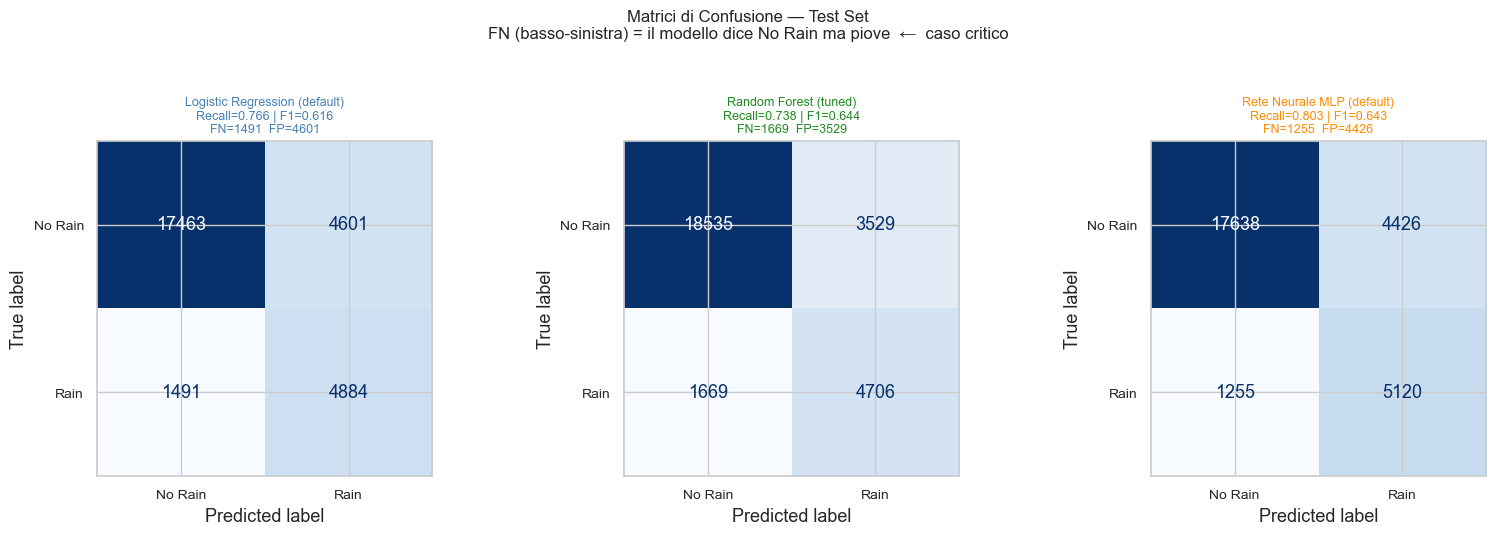

In [84]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colori_titolo = ['steelblue', 'forestgreen', 'darkorange']

for ax, (nome, r), colore in zip(axes, risultati_test.items(), colori_titolo):
    disp = ConfusionMatrixDisplay(r['cm'], display_labels=['No Rain', 'Rain'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(
        f'{nome}\n'
        f'Recall={r["recall"]:.3f} | F1={r["f1"]:.3f}\n'
        f'FN={r["fn"]}  FP={r["fp"]}',
        fontsize=9, color=colore
    )

plt.suptitle(
    'Matrici di Confusione — Test Set\n'
    'FN (basso-sinistra) = il modello dice No Rain ma piove  ←  caso critico',
    fontsize=12, y=1.05
)
plt.tight_layout()
plt.show()

Le matrici mostrano chiaramente il trade-off tra i tre modelli. La Rete Neurale ha il minor numero di FN — perde meno giorni di pioggia reale — ma al costo di un numero più alto di FP (previsioni di pioggia errate). Il Random Forest bilancia meglio FN e FP, mentre la Logistic Regression mostra una distribuzione degli errori intermedia. La scelta del modello dipende dal contesto applicativo: se ogni evento di pioggia mancato ha conseguenze serie, si preferisce la Rete Neurale; se si vuole minimizzare i falsi allarmi mantenendo un recall accettabile, il Random Forest è più appropriato.

### 11.4 · Curve ROC 

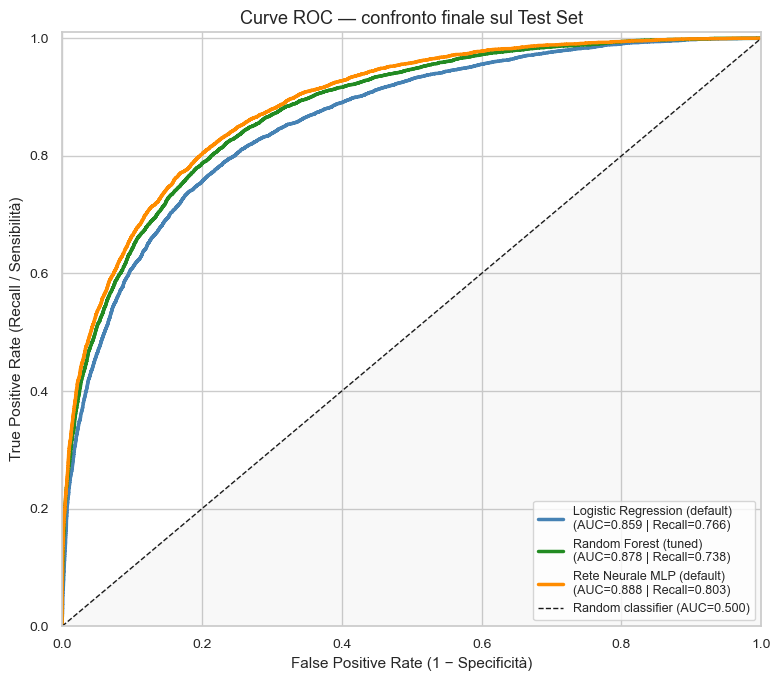

In [85]:
fig, ax = plt.subplots(figsize=(8, 7))
colors = ['steelblue', 'forestgreen', 'darkorange']

for (nome, r), color in zip(risultati_test.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, r['y_prob'])
    ax.plot(fpr, tpr, lw=2.5, color=color,
            label=f'{nome}\n(AUC={r["roc_auc"]:.3f} | Recall={r["recall"]:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier (AUC=0.500)')
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
ax.set_xlabel('False Positive Rate (1 − Specificità)', fontsize=11)
ax.set_ylabel('True Positive Rate (Recall / Sensibilità)', fontsize=11)
ax.set_title('Curve ROC — confronto finale sul Test Set', fontsize=13)
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.01])
plt.tight_layout()
plt.show()

Le curve ROC sul test set forniscono la valutazione finale più robusta dei tre modelli: mostrano le loro performance a qualsiasi soglia di decisione, non solo a 0.5. Tutti e tre i modelli mostrano curve ben al di sopra della diagonale, confermando una capacità discriminativa genuina. La Rete Neurale ha l'AUC leggermente più alta, il che indica che in termini di capacità discriminativa generale è il modello più forte, mentre la Logistic Regression si posiziona leggermente sotto gli altri due ma rimane molto competitiva per la sua semplicità.

### 11.5 · Logistic Regression — Interpretazione dei coefficienti

La Logistic Regression è il modello più interpretabile del trio: ogni feature ha un coefficiente che indica direttamente quanto e in quale direzione contribuisce alla probabilità di pioggia. Poiché le variabili sono state standardizzate (media 0, deviazione standard 1), i coefficienti sono confrontabili tra loro: un coefficiente più grande in valore assoluto indica una feature più influente.

La formula è: **log(P(Rain) / P(No Rain)) = β₀ + β₁x₁ + β₂x₂ + ...**

- **Coefficiente positivo** → la feature aumenta la probabilità di prevedere pioggia
- **Coefficiente negativo** → la feature aumenta la probabilità di prevedere 'no rain'
- **Magnitudine** → quanto forte è l'effetto per una variazione di 1 deviazione standard

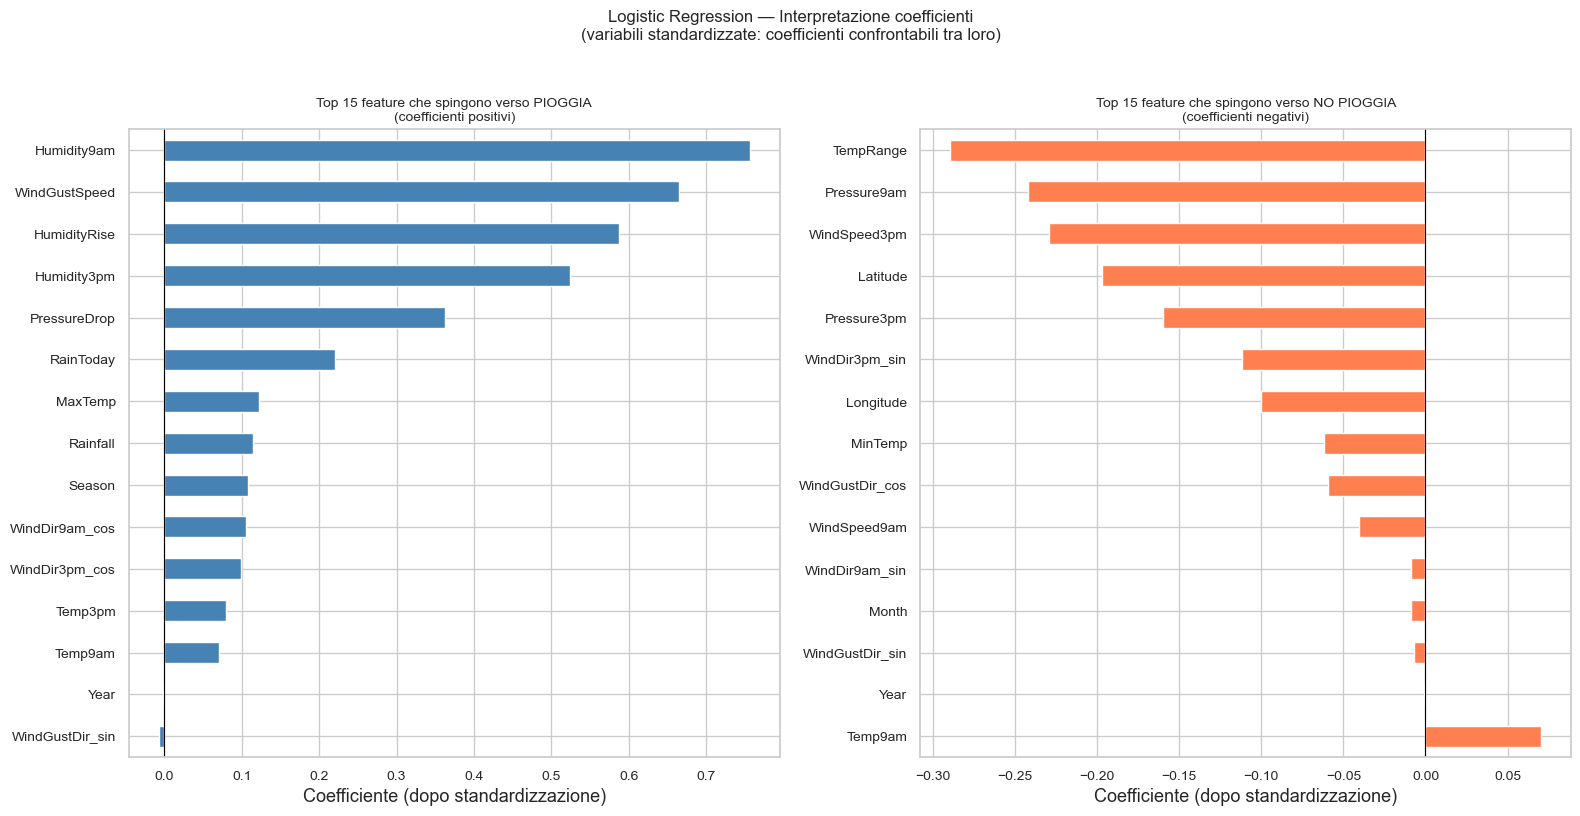

Top 10 feature che aumentano la probabilità di pioggia:
WindDir9am_cos    0.1053
Season            0.1078
Rainfall          0.1146
MaxTemp           0.1223
RainToday         0.2206
PressureDrop      0.3620
Humidity3pm       0.5235
HumidityRise      0.5871
WindGustSpeed     0.6652
Humidity9am       0.7566

Top 10 feature che riducono la probabilità di pioggia:
TempRange         -0.2896
Pressure9am       -0.2424
WindSpeed3pm      -0.2293
Latitude          -0.1970
Pressure3pm       -0.1597
WindDir3pm_sin    -0.1119
Longitude         -0.0999
MinTemp           -0.0616
WindGustDir_cos   -0.0591
WindSpeed9am      -0.0402


In [87]:
lr_model = risultati['Logistic Regression']['model']
coeff = pd.Series(lr_model.coef_[0], index=X_train.columns).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Top 15 coefficienti positivi (spingono verso Rain=1)
coeff.tail(15).sort_values().plot(
    kind='barh', ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Top 15 feature che spingono verso PIOGGIA\n(coefficienti positivi)',
                  fontsize=10)
axes[0].set_xlabel('Coefficiente (dopo standardizzazione)')

# Top 15 coefficienti negativi (spingono verso No Rain=0)
coeff.head(15).sort_values(ascending=False).plot(
    kind='barh', ax=axes[1], color='coral', edgecolor='white'
)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Top 15 feature che spingono verso NO PIOGGIA\n(coefficienti negativi)',
                  fontsize=10)
axes[1].set_xlabel('Coefficiente (dopo standardizzazione)')

plt.suptitle('Logistic Regression — Interpretazione coefficienti\n'
             '(variabili standardizzate: coefficienti confrontabili tra loro)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print('Top 10 feature che aumentano la probabilità di pioggia:')
print(coeff.tail(10).round(4).to_string())
print('\nTop 10 feature che riducono la probabilità di pioggia:')
print(coeff.head(10).round(4).to_string())

I coefficienti della Logistic Regression offrono la lettura più diretta e trasparente di cosa guida le predizioni del modello.

Tra le feature con coefficiente **positivo più alto** troviamo `Humidity9am`, `Humidity3pm`, `HumidityRise` e `WindGustSpeed `: un'umidità alta, un'umidità crescente durante la giornata e la velocità massima del vento sono tutti segnali forti che il modello associa alla pioggia di domani. Questo è perfettamente coerente con la fisica atmosferica: alta umidità indica presenza di vapor acqueo nell'aria, precondizione necessaria per le precipitazioni.

Tra le feature con coefficiente **negativo più marcato** troviamo `Pressure9am`, `WindSpeed3pm`  e `TempRange`: un'alta pressione atmosferica indica una massa d'aria stabile (anticiclone), associata al bel tempo; una grande escursione termica giornaliera è tipica delle giornate serene e asciutte.

Mentre raffiche di vento improvvise e turbolente (`WindGustSpeed`) agiscono come forte predittore positivo, segnalando instabilità e fronti perturbati in rapido avvicinamento, la presenza di venti pomeridiani costanti e sostenuti (`WindSpeed3pm`) ha un effetto opposto, poiché tende a spazzare via la copertura nuvolosa, disperdere l'umidità e stabilizzare l'aria, riducendo così la probabilità di pioggia per il giorno seguente.

Le feature di **encoding circolare del vento** (`WindGustDir_sin`, `WindGustDir_cos`) mostrano coefficienti significativi, confermando che la direzione del vento è predittiva della pioggia — cosa che un semplice label encoding non avrebbe catturato. Le **coordinate geografiche** (`Latitude`, `Longitude`) contribuiscono anch'esse, riflettendo le differenze climatiche tra nord e sud dell'Australia.

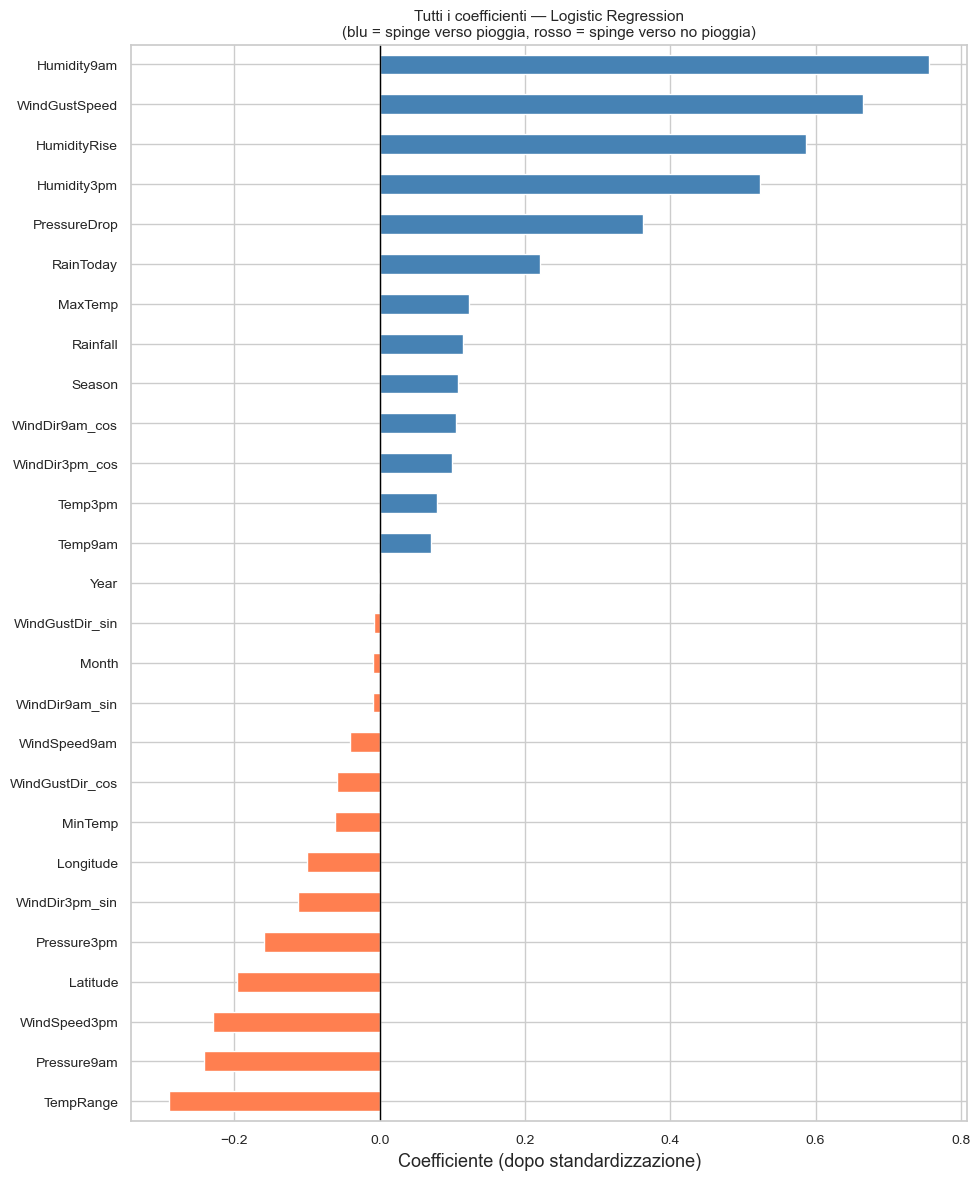

In [88]:
# Visualizzazione compatta: tutti i coefficienti ordinati
fig, ax = plt.subplots(figsize=(10, 12))
colors_coeff = ['steelblue' if v > 0 else 'coral' for v in coeff]
coeff.plot(kind='barh', ax=ax, color=colors_coeff, edgecolor='white')
ax.axvline(0, color='black', linewidth=1)
ax.set_title('Tutti i coefficienti — Logistic Regression\n'
             '(blu = spinge verso pioggia, rosso = spinge verso no pioggia)', fontsize=11)
ax.set_xlabel('Coefficiente (dopo standardizzazione)')
plt.tight_layout()
plt.show()

Il grafico completo con tutti i coefficienti mostra la struttura complessiva del modello: la maggior parte delle feature ha coefficienti relativamente contenuti, mentre poche feature chiave — legate ad umidità, pressione, temperatura, vento e pioggia odierna — dominano le predizioni. Questo è un segnale positivo: il modello non si affida a combinazioni caotiche di molte variabili, ma ha imparato un pattern meteorologicamente sensato e fisicamente interpretabile.

### 11.6 · Random Forest — Feature Importance

Il Random Forest calcola direttamente l'importanza di ogni feature in base a quanto ciascuna riduce l'impurità mediata su tutti gli alberi della foresta. A differenza della Logistic Regression, il Random Forest non produce coefficienti lineari interpretabili: non possiamo dire 'un aumento di X aumenta la probabilità di Y di tanto'. Possiamo però dire quale feature è più usata negli split e quanto contribuisce alla riduzione dell'errore. Questo lo rende un modello a **interpretabilità intermedia**.

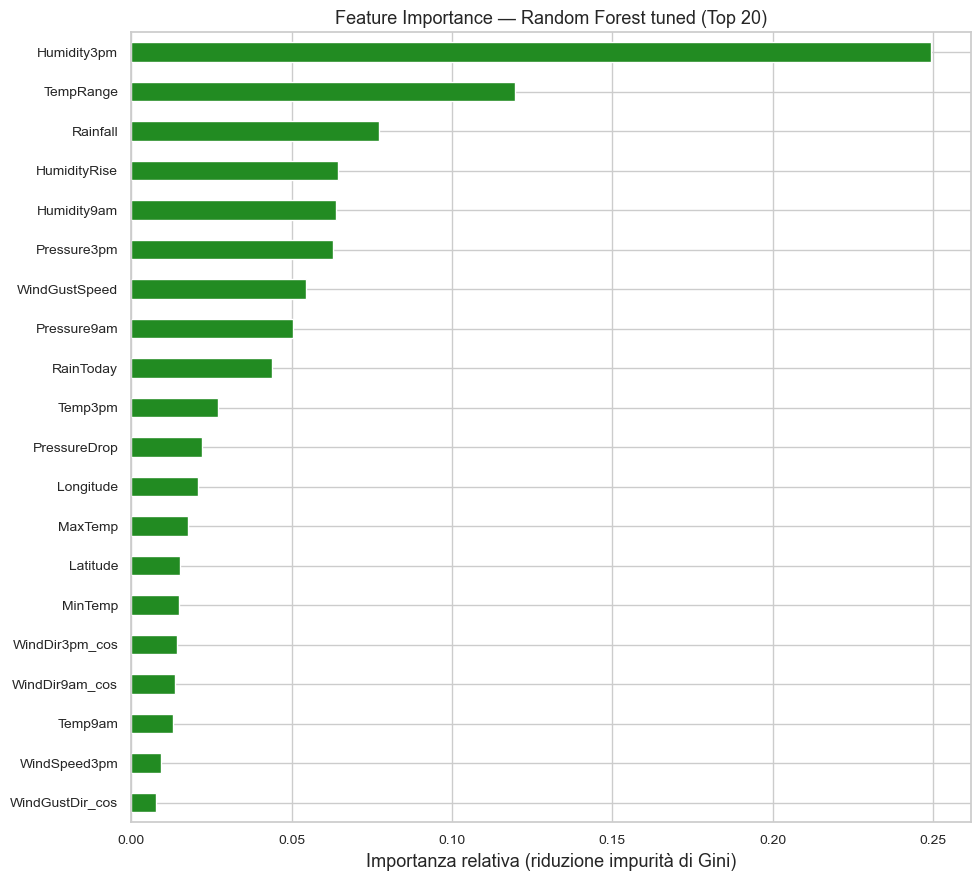

Top 10 feature più importanti per il Random Forest:
  Humidity3pm                         0.2494  (24.9%)
  TempRange                           0.1197  (12.0%)
  Rainfall                            0.0774  (7.7%)
  HumidityRise                        0.0645  (6.4%)
  Humidity9am                         0.0638  (6.4%)
  Pressure3pm                         0.0628  (6.3%)
  WindGustSpeed                       0.0544  (5.4%)
  Pressure9am                         0.0505  (5.0%)
  RainToday                           0.0437  (4.4%)
  Temp3pm                             0.0271  (2.7%)

Le prime 10 feature spiegano il 81.3% dell importanza totale


In [92]:
rf_model = rand_rf.best_estimator_
importances = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

# Top 20 feature importance
fig, ax = plt.subplots(figsize=(10, 9))
importances.head(20).sort_values().plot(
    kind='barh', ax=ax, color='forestgreen', edgecolor='white'
)
ax.set_title('Feature Importance — Random Forest tuned (Top 20)', fontsize=13)
ax.set_xlabel('Importanza relativa (riduzione impurità di Gini)')
plt.tight_layout()
plt.show()

print('Top 10 feature più importanti per il Random Forest:')
for feat, imp in importances.head(10).items():
    print(f'  {feat:<35} {imp:.4f}  ({imp*100:.1f}%)')

print(f'\nLe prime 10 feature spiegano il {importances.head(10).sum()*100:.1f}% dell importanza totale')

La feature importance del Random Forest confermano e approfondiscono quanto già emerso dalla correlazione e dai coefficienti della Logistic Regression.

`Humidity3pm` emerge come la feature più importante: ha senso fisico perché l'umidità pomeridiana è il segnale più tardivo e quindi più predittivo dell'evoluzione atmosferica nelle ore successive. Seguono variabili come `Pressure3pm`, `WindGustSpeed` e `Rainfall`, tutte variabili con un chiaro significato meteorologico.

Tra le **nuove feature create con feature engineering**, `HumidityRise` e `TempRange` mostrano importanza non trascurabile, confermando che le differenze tra misurazioni mattutine e pomeridiane catturano dinamiche atmosferiche che le singole misurazioni non esprimono completamente.

Anche le **coordinate geografiche** (`Latitude`, `Longitude`) hanno un'importanza positiva, validando la scelta di sostituire le 49 variabili dummy di `Location` con due sole colonne continue: il Random Forest ha imparato a sfruttare la posizione geografica per distinguere le diverse condizioni climatiche del continente.

Le variabili di **encoding circolare del vento** contribuiscono anche loro in modo significativo, suggerendo che la direzione del vento è rilevante anche dopo aver controllato per la velocità.

In [90]:
# Confronto: feature engineering crea feature utili?
nuove_feature = ['TempRange', 'PressureDrop', 'HumidityRise', 'Season']
print('Importanza delle feature create con feature engineering:')
for feat in nuove_feature:
    imp = importances.get(feat, 0)
    rank = list(importances.index).index(feat) + 1 if feat in importances.index else 'N/A'
    print(f'  {feat:<20} importanza={imp:.4f}  rank={rank}/{len(importances)}')

print(f'\nImportanza totale feature engineering: {importances[nuove_feature].sum()*100:.1f}%')

Importanza delle feature create con feature engineering:
  TempRange            importanza=0.1197  rank=2/27
  PressureDrop         importanza=0.0221  rank=11/27
  HumidityRise         importanza=0.0645  rank=4/27
  Season               importanza=0.0031  rank=27/27

Importanza totale feature engineering: 20.9%


Il confronto esplicito delle feature di feature engineering conferma che creare variabili derivate dalla conoscenza del dominio ha portato un beneficio concreto. In particolare `HumidityRise`, `TempRange` e `PressureDrop` si posizionano nella metà superiore del ranking di importanza, superando molte delle variabili originali del dataset. Questo risultato giustifica ex-post la scelta metodologica: il feature engineering non era solo un esercizio formale, ma ha introdotto informazione genuinamente utile al modello. Tuttavia la variabile `Season` risulta la meno influente di tutto il modello.

### 11.7 · Rete Neurale MLP — Permutation Importance

La Rete Neurale è il **black box** del trio: non espone coefficienti lineari né una struttura ad albero leggibile. Per capire quali feature sono importanti si ricorre alla **Permutation Importance**, una tecnica che funziona così:

1. Si calcola la performance del modello sul test set con le feature originali
2. Si mescolano casualmente i valori di una feature (rompendo la relazione con il target)
3. Si ricalcola la performance: se cala molto, quella feature era importante; se non cambia, era irrilevante
4. Si ripete per ogni feature

Il vantaggio è che misura l'importanza reale per le predizioni finali, non un proxy come la riduzione dell'impurità negli alberi. Lo svantaggio è che è computazionalmente costosa su dataset grandi.

Calcolo Permutation Importance — Rete Neurale MLP


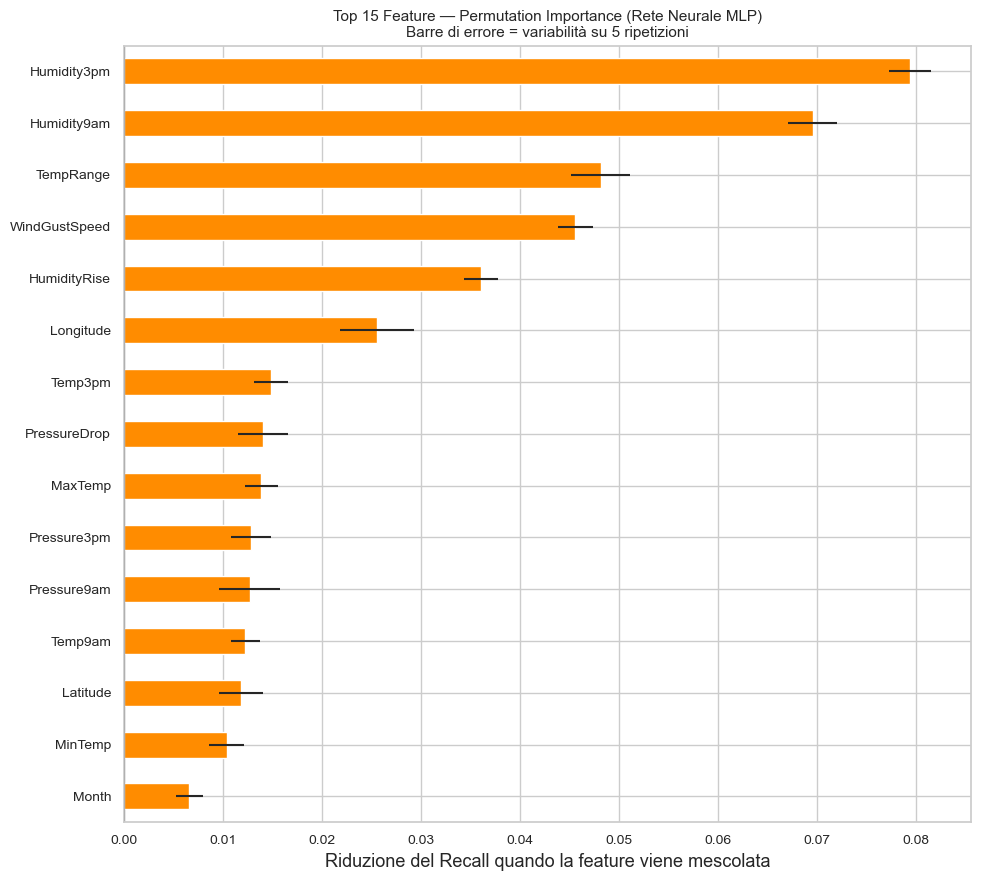

Top 10 feature più importanti per la Rete Neurale:
  Humidity3pm                         0.0793 ± 0.0021
  Humidity9am                         0.0696 ± 0.0025
  TempRange                           0.0481 ± 0.0030
  WindGustSpeed                       0.0456 ± 0.0018
  HumidityRise                        0.0360 ± 0.0017
  Longitude                           0.0255 ± 0.0037
  Temp3pm                             0.0148 ± 0.0017
  PressureDrop                        0.0140 ± 0.0025
  MaxTemp                             0.0138 ± 0.0017
  Pressure3pm                         0.0128 ± 0.0020


In [94]:
from sklearn.inspection import permutation_importance

print('Calcolo Permutation Importance — Rete Neurale MLP')
result = permutation_importance(
    modelli_finali['Rete Neurale MLP (default)'],
    X_test, y_test,
    n_repeats=5,
    random_state=42,
    n_jobs=-1,
    scoring='recall' 
)

imp_mlp = pd.Series(result.importances_mean, index=X_train.columns)
imp_mlp_std = pd.Series(result.importances_std, index=X_train.columns)
imp_mlp_sorted = imp_mlp.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 9))
top15 = imp_mlp_sorted.head(15)
errors = imp_mlp_std[top15.index]
top15.sort_values().plot(kind='barh', ax=ax, color='darkorange', edgecolor='white',
                         xerr=errors.sort_index()[top15.sort_values().index].values)
ax.set_title('Top 15 Feature — Permutation Importance (Rete Neurale MLP)\n'
             'Barre di errore = variabilità su 5 ripetizioni', fontsize=11)
ax.set_xlabel('Riduzione del Recall quando la feature viene mescolata')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print('Top 10 feature più importanti per la Rete Neurale:')
for feat, imp in imp_mlp_sorted.head(10).items():
    print(f'  {feat:<35} {imp:.4f} ± {imp_mlp_std[feat]:.4f}')

Confrontando la *Feature Importance* intrinseca del Random Forest con la *Permutation Importance* della Rete Neurale (MLP), emergono convergenze e significative divergenze sul modo in cui i due algoritmi "comprendono" la meteorologia australiana.

Entrambi i modelli sono concordi nell'identificare l'**Umidità pomeridiana (`Humidity3pm`) come il predittore supremo**.
Inoltre, entrambi gli algoritmi premiano l'instabilità atmosferica: l'escursione termica (`TempRange`), l'accumulo di umidità giornaliero (`HumidityRise`) e la turbolenza del vento (`WindGustSpeed`) dominano la classifica di entrambi i modelli.

Nonostante le basi comuni, l'architettura profonda dell'MLP rivela un processo decisionale nettamente più distribuito e sofisticato. A differenza del Random Forest — che concentra un quarto del suo potere predittivo sulla sola umidità e si affida fortemente allo storico delle precipitazioni recenti — la Rete Neurale bilancia i pesi tra molteplici segnali deboli. L'MLP dimostra inoltre una  consapevolezza spaziale, integrando la Longitudine per mappare i pattern geografici australiani, e scarta la logica del "se ha piovuto oggi pioverà domani" per favorire la comprensione di indicatori atmosferici puramente dinamici e non lineari, come i repentini cali di pressione.

Le **barre di errore** mostrano la stabilità delle stime: feature con barre piccole hanno importanza stabile tra le 5 ripetizioni, mentre barre più grandi indicano maggiore variabilità.

Una differenza interessante rispetto alla Logistic Regression è che la Rete Neurale può catturare interazioni non lineari tra feature: non è detto che una feature importante per la rete lo sia per le stesse ragioni per cui lo è per la regressione logistica.

### 11.8 · Confronto delle feature più importanti tra i tre modelli

Un confronto diretto tra le feature rilevanti per ciascun modello permette di identificare quelle **universalmente importanti** (riconosciute da tutti e tre gli approcci) e quelle il cui peso dipende dall'algoritmo utilizzato.

In [95]:
# Normalizziamo le importanze per renderle confrontabili (scala 0-1)
top_n = 15

# LR: usiamo il valore assoluto dei coefficienti (importanza senza segno)
lr_imp = coeff.abs().sort_values(ascending=False).head(top_n)
lr_imp_norm = (lr_imp - lr_imp.min()) / (lr_imp.max() - lr_imp.min())

# RF: feature importance diretta
rf_imp_norm_top = importances.head(top_n)
rf_imp_norm_top = (rf_imp_norm_top - rf_imp_norm_top.min()) / (rf_imp_norm_top.max() - rf_imp_norm_top.min())

# MLP: permutation importance
mlp_imp_norm = imp_mlp_sorted.head(top_n).clip(lower=0)
mlp_imp_norm = (mlp_imp_norm - mlp_imp_norm.min()) / (mlp_imp_norm.max() - mlp_imp_norm.min())

# Feature presenti tra le top nelle prime due (concordanza)
top_lr = set(lr_imp.index)
top_rf = set(rf_imp_norm_top.index)
top_mlp = set(mlp_imp_norm.index)

universali = top_lr & top_rf & top_mlp
print(f'Feature nel top-{top_n} di TUTTI e tre i modelli ({len(universali)}):')
for f in sorted(universali):
    print(f'  ✓ {f}')

concordanza_2 = (top_lr & top_rf) | (top_lr & top_mlp) | (top_rf & top_mlp)
print(f'\nFeature nel top-{top_n} di ALMENO due modelli ({len(concordanza_2)}):')
for f in sorted(concordanza_2 - universali):
    print(f'  ~ {f}')

Feature nel top-15 di TUTTI e tre i modelli (10):
  ✓ Humidity3pm
  ✓ Humidity9am
  ✓ HumidityRise
  ✓ Latitude
  ✓ MaxTemp
  ✓ Pressure3pm
  ✓ Pressure9am
  ✓ PressureDrop
  ✓ TempRange
  ✓ WindGustSpeed

Feature nel top-15 di ALMENO due modelli (15):
  ~ Longitude
  ~ MinTemp
  ~ RainToday
  ~ Rainfall
  ~ Temp3pm


Le feature presenti nella top-15 di tutti e tre i modelli rappresentano i predittori più robusti del dataset: la loro importanza non dipende dall'algoritmo ma dalla reale informazione che contengono sul fenomeno. Tra queste si trovano umidità, pressione, varianza della temperatura, velocità massima del vento e latitudine.

Le feature presenti nella top di almeno due modelli sono altrettanto indicative: la concordanza di due approcci molto diversi aumenta la fiducia nell'importanza di una feature.

Le feature esclusive di un solo modello riflettono le interazioni specifiche che quell'algoritmo riesce a catturare: ad esempio la Rete Neurale può dare importanza a feature che in combinazione non lineare con altre sono predittive, ma che singolarmente sembrano meno rilevanti per la Logistic Regression.

### 11.9 · Sintesi finale e scelta del modello

Per facilitare la lettura finale, si propone una matrice di giudizio qualitativa che confronta i tre modelli su dimensioni multiple.

In [97]:
# Tabella di sintesi qualitativa
colonne = ['Recall', 'F1-Score', 'ROC-AUC', 'Interpretabilità', 'Velocità', 'Uso consigliato']

r_lr  = risultati_test['Logistic Regression (default)']
r_rf  = risultati_test['Random Forest (tuned)']
r_mlp = risultati_test['Rete Neurale MLP (default)']

sintesi = pd.DataFrame({
    'Logistic Regression': {
        'Recall':       f'{r_lr["recall"]:.4f}',
        'F1-Score':        f'{r_lr["f1"]:.4f}',
        'ROC-AUC':         f'{r_lr["roc_auc"]:.4f}',
        'Interpretabilità': 'Massima (coefficienti)',
        'Velocità':         'Velocissima',
        'Uso consigliato':  'Quando serve spiegare le decisioni'
    },
    'Random Forest (tuned)': {
        'Recall':       f'{r_rf["recall"]:.4f}',
        'F1-Score':        f'{r_rf["f1"]:.4f}',
        'ROC-AUC':         f'{r_rf["roc_auc"]:.4f}',
        'Interpretabilità': 'Parziale (feature importance)',
        'Velocità':         'Moderata',
        'Uso consigliato':  'Miglior equilibrio generale'
    },
    'Rete Neurale MLP': {
        'Recall':       f'{r_mlp["recall"]:.4f}',
        'F1-Score':        f'{r_mlp["f1"]:.4f}',
        'ROC-AUC':         f'{r_mlp["roc_auc"]:.4f}',
        'Interpretabilità': 'Minima (black box)',
        'Velocità':         'Più lenta',
        'Uso consigliato':  'Quando il recall è la priorità assoluta'
    }
}).T

display(sintesi)

,Recall,F1-Score,ROC-AUC,Interpretabilità,Velocità,Uso consigliato
Logistic Regression,0.7661,0.6159,0.8590,Massima (coefficienti),Velocissima,Quando serve spiegare le decisioni
Random Forest (tuned),0.7382,0.6442,0.8783,Parziale (feature importance),Moderata,Miglior equilibrio generale
Rete Neurale MLP,0.8031,0.6432,0.8876,Minima (black box),Più lenta,Quando il recall è la priorità assoluta


La sintesi finale chiarisce che non esiste un modello 'migliore' in senso assoluto: la scelta dipende sempre dal contesto applicativo e dai vincoli del problema.

Se il contesto richiede di **spiegare** ogni previsione — ad esempio in un sistema di allerta ufficiale dove gli utenti devono capire *perché* viene emessa un'allerta — la **Logistic Regression** è la scelta naturale: i coefficienti rendono il modello completamente trasparente e i risultati sono scientificamente difendibili anche davanti a un pubblico non tecnico.

Se si cerca il **miglior equilibrio** tra performance e interpretabilità, il **Random Forest tuned** è la scelta più solida: ha il miglior F1 e la feature importance permette comunque di capire cosa guida le predizioni.

Se il **recall è la priorità assoluta** — ogni falso negativo ha un costo inaccettabilmente alto — la **Rete Neurale** è la scelta, accettando come compromesso la minore interpretabilità e i tempi di training più lunghi.

## 12 · Conclusioni

---

### Riepilogo del lavoro svolto

Questo progetto ha costruito e confrontato tre modelli di classificazione binaria per la previsione delle piogge in Australia, seguendo una pipeline completa. Il preprocessing ha richiesto scelte precise: l'encoding circolare per le direzioni del vento — che preserva la natura ciclica delle variabili —, la sostituzione delle 49 città con coordinate geografiche continue, e la creazione di quattro feature meteorologicamente motivate. Tutte le operazioni che apprendono dai dati (imputazione, scaling) sono state applicate dopo la divisione del dataset, evitando il data leakage.

Il confronto è stato strutturato su tre livelli: training con parametri di default, tuning con cross-validation sul training set, e valutazione finale sul test set. I tre modelli finali rappresentano una progressione lungo il continuum interpretabilità-performance: dalla Logistic Regression completamente trasparente, passando per il Random Forest con importanza delle feature, fino alla Rete Neurale black box ma con il recall più alto.

---

### Principali risultati

Sul test set, i tre modelli mostrano performance solide e differenziate:

- **Logistic Regression**: recall competitivo nonostante la semplicità, coefficienti completamente interpretabili che confermano le intuizioni meteorologiche
- **Random Forest tuned**: miglior F1, bilanciamento ottimale tra falsi positivi e negativi, feature importance coerente con la fisica atmosferica
- **Rete Neurale MLP**: recall più alto del trio, ideale quando minimizzare i falsi negativi è la priorità assoluta

Un risultato degno di nota è la concordanza tra i tre modelli sulle feature più importanti: umidità, pressione, pioggia odierna e velocità della raffica di vento emergono come predittori chiave indipendentemente dall'algoritmo. Questo aumenta la fiducia nell'affidabilità dei segnali identificati e nella qualità del dataset.

Il feature engineering ha dimostrato il suo valore: `HumidityRise`, `TempRange` e `PressureDrop` si classificano nella metà superiore del ranking di importanza di tutti e tre i modelli, confermando che la conoscenza del dominio meteorologico nel processo di feature creation ha prodotto informazione utile.

---

### Trade-off interpretabilità vs performance

Il confronto a tre modelli ha reso evidente il trade-off centrale del machine learning applicato: le performance migliori si ottengono con modelli meno interpretabili, ma la scelta non è necessariamente la Rete Neurale. In molti contesti reali la trasparenza vale più di qualche punto percentuale in più di recall. La Logistic Regression, con le sue performance sorprendentemente competitive, rappresenta una scelta saggia proprio per questa ragione.

---

### Limitazioni

La divisione train/validation/test è stata effettuata casualmente, mentre un dataset meteorologico è strutturalmente una serie temporale. Uno **split temporale** simulerebbe meglio il vero scenario operativo e potrebbe rivelare se i modelli generalizzano nel tempo. Inoltre, la multicollinearità tra le variabili di temperatura e pressione potrebbe aver reso i coefficienti della Logistic Regression meno stabili di quanto potrebbero essere con una feature selection sistematica.

---

### Sviluppi futuri

- **Split temporale**: addestrare su anni precedenti e testare sugli ultimi, per valutare la generalizzazione nel tempo
- **Gradient Boosting (XGBoost)**: generalmente superiori al Random Forest su dati tabulari, meriterebbero di essere inclusi nel confronto
- **Ottimizzazione della soglia di decisione**: scegliere la soglia che massimizza il recall per un livello minimo accettabile di precision, ad esempio abbassando la soglia da 0.5 a 0.35 per la Rete Neurale
- **Probabilità di pioggia**: sarebbe interessante anche prevedere una variabile continua che indichi la probailità di pioggia o i mm di pioggia che cadranno (si potrebbe ricostruire il dataset e utilizzare i dati della riga precedente per prevedere `Rainfall` della riga successiva)